# Deep Learning (DLY0100) - Sección 012V
## Perceptrón Multicapa (MLP) para clasificación — Experimentación controlada

**Evaluación:** Evaluación Parcial 1

**Integrantes:** Luis Muñoz, Aran Opazo

**Fecha:** Por definir



---

Este notebook implementa y evalúa un Perceptrón Multicapa (MLP) para clasificar radiografías según el tipo de fractura ósea.

**Problema:** dada una radiografía, identificar a cuál de los 10 tipos de fractura corresponde (avulsión, conminuta, fractura-luxación, en tallo verde, fisura, impactada, longitudinal, oblicua, patológica y espiral). Cada imagen pertenece a una sola clase, por lo que es un problema de clasificación multiclase.

**Objetivo del modelo:** entrenar un MLP con TensorFlow/Keras y evaluarlo con accuracy, precision, recall y F1-score.

**Objetivo experimental:** analizar, mediante experimentos controlados (cambiando un parámetro a la vez), cómo influyen la arquitectura, el learning rate, el batch size, las épocas, las funciones de activación y pérdida, y la regularización en el desempeño del modelo.

**Origen del trabajo:** este notebook toma como punto de partida el MLP desarrollado por el mismo equipo en la asignatura Técnicas Avanzadas de Machine Learning (TLY1102), adaptado al nuevo dataset y ampliado según los requerimientos de esta evaluación.

> Nota: este es un proyecto académico; el modelo no está pensado para uso clínico ni diagnóstico.

### Estructura del notebook

0. Configuración del entorno
1. Dataset: descripción y descarga
2. Exploración del dataset
3. Particiones y preprocesamiento
4. Métricas y herramientas de experimentación
5. Experimentos controlados y selección del modelo
6. Evaluación final en test
7. Análisis de errores
8. Conclusiones y mejoras propuestas
9. Reproducción y referencias


## 0. Configuración del entorno

### 0.1 Librerías

- **NumPy / Pandas:** manejo de arreglos y tablas de resultados.
- **Matplotlib / Seaborn:** gráficos.
- **PIL (Pillow):** lectura de imágenes.
- **scikit-learn:** partición estratificada de los datos y cálculo de métricas.
- **TensorFlow / Keras:** construcción y entrenamiento del MLP (capas `Dense`, `Dropout`, `BatchNormalization`, regularización L2, optimizadores y funciones de pérdida). Se usa Keras porque permite definir el MLP capa por capa de forma legible y trae implementadas todas las funciones que se comparan en este trabajo.


In [1]:
import os, sys, json, time, random, hashlib, platform, datetime, zipfile
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # para ocultar mensajes informativos de TensorFlow

# Si el notebook se ejecuta desde la carpeta notebooks/, se sube a la raíz del proyecto
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             log_loss, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

tf.get_logger().setLevel("ERROR")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
print("Directorio de trabajo:", os.getcwd())
print("TensorFlow:", tf.__version__)

Directorio de trabajo: /content
TensorFlow: 2.20.0


## 0.2 Reproducibilidad

Se fija una semilla (SEED = 42) y se activa el modo determinista de TensorFlow. Sin esto, cada ejecución inicializa los pesos y ordena los lotes de forma distinta, y los resultados cambian entre corridas.

- La semilla se definió antes de realizar cualquier experimento y no se eligió por entregar el mejor resultado.
- Antes de cada experimento se llama a reiniciar_semillas(), de modo que todos los modelos parten de las mismas condiciones: dos modelos con la misma arquitectura comienzan con pesos iniciales idénticos. Así, la diferencia entre dos experimentos se debe al parámetro que se cambió y no al azar.
- El efecto del azar se estudia aparte (sección 5.13), reportando promedio y variabilidad en vez de elegir la mejor semilla.

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()   # operaciones deterministas en TensorFlow

def reiniciar_semillas(seed=None):
    """Restablece todas las fuentes de aleatoriedad (Python, NumPy y TensorFlow)."""
    seed = SEED if seed is None else seed
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

reiniciar_semillas()
print("Semilla fija:", SEED)

Semilla fija: 42


### 0.3 Carpetas del proyecto

Se crean (si no existen) las carpetas donde se guardan los datos descargados, el modelo final, las figuras y las tablas de resultados

In [3]:
for carpeta in ["data", "models", "images", "results"]:
    os.makedirs(carpeta, exist_ok=True)
print("Contenido del directorio de trabajo:", sorted(os.listdir(".")))

Contenido del directorio de trabajo: ['.config', 'data', 'images', 'models', 'results', 'sample_data']


## 1. Dataset: descripción y descarga

- **Nombre:** Bone Break Classification Image Dataset
- **Fuente:** Kaggle — https://www.kaggle.com/datasets/pkdarabi/bone-break-classification-image-dataset
- **Contenido:** radiografías de 10 tipos de fractura ósea.
- **Variable objetivo:** el tipo de fractura, indicado por la carpeta en la que está cada imagen.
- **Particiones originales:** el autor del dataset ya separó las imágenes de cada clase en una carpeta Train y otra Test.

La descarga usa el token de Kaggle guardado en los Secrets de Colab con el nombre KAGGLE_TOKEN. Si el dataset ya está descargado en la sesión, no se vuelve a descargar.

In [4]:
KAGGLE_DATASET = "pkdarabi/bone-break-classification-image-dataset"
RUTA_ZIP = "data/bone-break-classification-image-dataset.zip"
RUTA_RAW = "data/bone_raw"          # carpeta donde se descomprime el dataset

if os.path.isdir(RUTA_RAW) and os.listdir(RUTA_RAW):
    print("El dataset ya está descomprimido en", RUTA_RAW)
else:
    # 1) Credenciales de Kaggle (en colab se lee desde secrets)
    try:
        from google.colab import userdata
        token = userdata.get("KAGGLE_TOKEN")
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
            f.write(token)
        os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)
    except ImportError:
        pass   # ejecución local: se espera el token en ~/.kaggle/
    except Exception as e:
        raise RuntimeError("No se encontró el secreto KAGGLE_TOKEN. Agrégalo en el panel 🔑 de Colab "
                           "y habilita el acceso para este notebook.") from e

    # 2) Descarga y descompresión
    codigo = os.system(f"kaggle datasets download -d {KAGGLE_DATASET} -p data -q")
    if codigo != 0 or not os.path.exists(RUTA_ZIP):
        raise RuntimeError("Falló la descarga desde Kaggle: revisa el token y la conexión.")
    with zipfile.ZipFile(RUTA_ZIP) as z:
        z.extractall(RUTA_RAW)
    print("Dataset descargado y descomprimido en", RUTA_RAW)

Dataset descargado y descomprimido en data/bone_raw


### 1.1 Estructura del dataset e inventario de imágenes

El dataset organiza las imágenes primero por clase y dentro por partición:

```
<tipo de fractura>/
├── Train/   ← imágenes de entrenamiento
└── Test/    ← imágenes de prueba
```

En vez de mover o copiar archivos, el código recorre esa estructura tal como viene y arma una tabla (inventario) con una fila por imagen: su ruta, su clase (nombre de la carpeta) y su partición (train o test).

Al mismo tiempo se verifica la integridad de cada archivo: que se pueda abrir, que no esté vacío ni dañado, y se registran su tamaño y modo de color. También se calcula un hash MD5 (una "huella digital" del archivo), que en la exploración del dataset (sección 2) permite detectar imágenes duplicadas.

In [5]:
EXTENSIONES = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

def encontrar_raiz(ruta):
    """Busca la carpeta cuyas subcarpetas (las clases) contienen una carpeta Train."""
    for actual, subcarpetas, _ in os.walk(ruta):
        if subcarpetas and all(
            any(s.lower() == "train" for s in os.listdir(os.path.join(actual, c))) for c in subcarpetas
        ):
            return actual
    raise FileNotFoundError(f"No se encontró la estructura <clase>/Train dentro de {ruta}")

RAIZ = encontrar_raiz(RUTA_RAW)
CLASES = sorted(d for d in os.listdir(RAIZ) if os.path.isdir(os.path.join(RAIZ, d)))
N_CLASES = len(CLASES)

filas = []
for clase in CLASES:
    for sub in os.listdir(os.path.join(RAIZ, clase)):
        particion = sub.lower()                        # "train" o "test"
        if particion not in ("train", "test"):
            continue
        carpeta = os.path.join(RAIZ, clase, sub)
        for archivo in sorted(os.listdir(carpeta)):
            if not archivo.lower().endswith(EXTENSIONES):
                continue
            ruta = os.path.join(carpeta, archivo)
            fila = {"ruta": ruta, "clase": clase, "particion": particion, "bytes": os.path.getsize(ruta),
                    "ok": False, "ancho": None, "alto": None, "modo": None, "hash": None}
            try:
                with open(ruta, "rb") as fh:
                    fila["hash"] = hashlib.md5(fh.read()).hexdigest()
                with Image.open(ruta) as im:
                    im.verify()                         # detecta archivos dañados
                with Image.open(ruta) as im:
                    fila["ancho"], fila["alto"], fila["modo"] = im.size[0], im.size[1], im.mode
                fila["ok"] = fila["bytes"] > 0
            except Exception:
                pass                                    # queda marcado como ok = False
            filas.append(fila)

df_inv = pd.DataFrame(filas)
print("Carpeta raíz del dataset:", RAIZ)
print(f"{N_CLASES} clases:", CLASES)
print("\nImágenes por partición original:\n", df_inv.groupby("particion").size().to_string())
print("\nArchivos vacíos o dañados:", int((~df_inv["ok"]).sum()))
display(df_inv.head())

Carpeta raíz del dataset: data/bone_raw/Bone Break Classification/Bone Break Classification
10 clases: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']

Imágenes por partición original:
 particion
test     140
train    989

Archivos vacíos o dañados: 0


,ruta,clase,particion,bytes,ok,ancho,alto,modo,hash
0,data/bone_raw/Bone Break Classification/Bone B...,Avulsion fracture,test,29536,True,640,640,RGB,35f35ef7ff77a754b0424ba244624b71
1,data/bone_raw/Bone Break Classification/Bone B...,Avulsion fracture,test,25542,True,640,640,RGB,822b34f85916f2c71eb4e97ce8d7bd89
2,data/bone_raw/Bone Break Classification/Bone B...,Avulsion fracture,test,42584,True,351,526,RGB,f3d65ad20464a2ea9e97901a95437acc
3,data/bone_raw/Bone Break Classification/Bone B...,Avulsion fracture,test,18449,True,286,603,RGB,add64921c4ae455b20e1c7449855ef16
4,data/bone_raw/Bone Break Classification/Bone B...,Avulsion fracture,test,33631,True,219,378,RGB,45d1e7a96370cdc6917490bac5224696


> Según la salida del bloque de código anterior se interpreta que el dataset se leyó correctamente: se encontraron las 10 clases de fractura, con 989 imágenes en las carpetas Train y 140 en las carpetas Test (1.129 en total). Ningún archivo está vacío ni dañado, por lo que no fue necesario excluir imágenes por problemas de lectura. La tabla muestra además que las imágenes vienen en tamaños muy distintos (por ejemplo, 640×640, 351×526 o 219×378), lo que se analiza en la sección 2.3.

## 2. Exploración del dataset

Cada análisis termina con una conclusión que conecta lo observado con una decisión de preprocesamiento o de modelado.

### 2.1 Distribución de clases (balance)

Para medir el balance se usa la razón de desbalance: imágenes de la clase más numerosa ÷ imágenes de la menos numerosa. Si la razón es cercana a 1, las clases están balanceadas; si es 2, una clase tiene el doble de ejemplos que otra y el modelo tenderá a favorecer a las más numerosas.

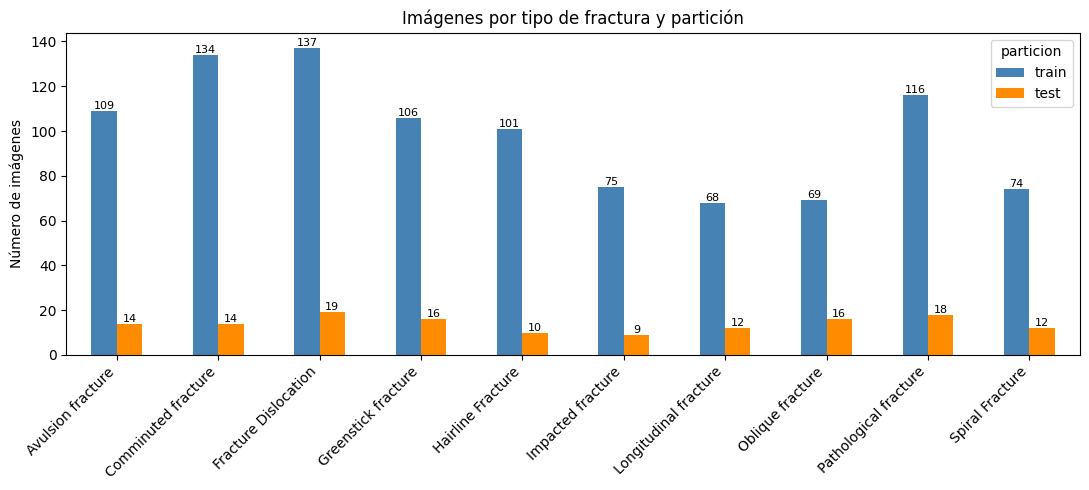

particion              test  train
clase                             
Avulsion fracture        14    109
Comminuted fracture      14    134
Fracture Dislocation     19    137
Greenstick fracture      16    106
Hairline Fracture        10    101
Impacted fracture         9     75
Longitudinal fracture    12     68
Oblique fracture         16     69
Pathological fracture    18    116
Spiral Fracture          12     74

Train → clase más numerosa: Fracture Dislocation (137) | menos numerosa: Longitudinal fracture (68) | razón de desbalance: 2.01


In [6]:
dist = df_inv[df_inv["ok"]].groupby(["clase", "particion"]).size().unstack().fillna(0).astype(int)

ax = dist[["train", "test"]].plot(kind="bar", figsize=(11, 5), color=["steelblue", "darkorange"])
for contenedor in ax.containers:
    ax.bar_label(contenedor, fontsize=8)
ax.set_title("Imágenes por tipo de fractura y partición")
ax.set_ylabel("Número de imágenes"); ax.set_xlabel("")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("images/distribucion_clases.png", dpi=150, bbox_inches="tight"); plt.show()

mayor, menor = dist["train"].max(), dist["train"].min()
print(dist)
print(f"\nTrain → clase más numerosa: {dist['train'].idxmax()} ({mayor}) | "
      f"menos numerosa: {dist['train'].idxmin()} ({menor}) | razón de desbalance: {mayor / menor:.2f}")

> **Interpretación (completar después de ejecutar)**

### 2.2 Ejemplos de cada tipo de fractura

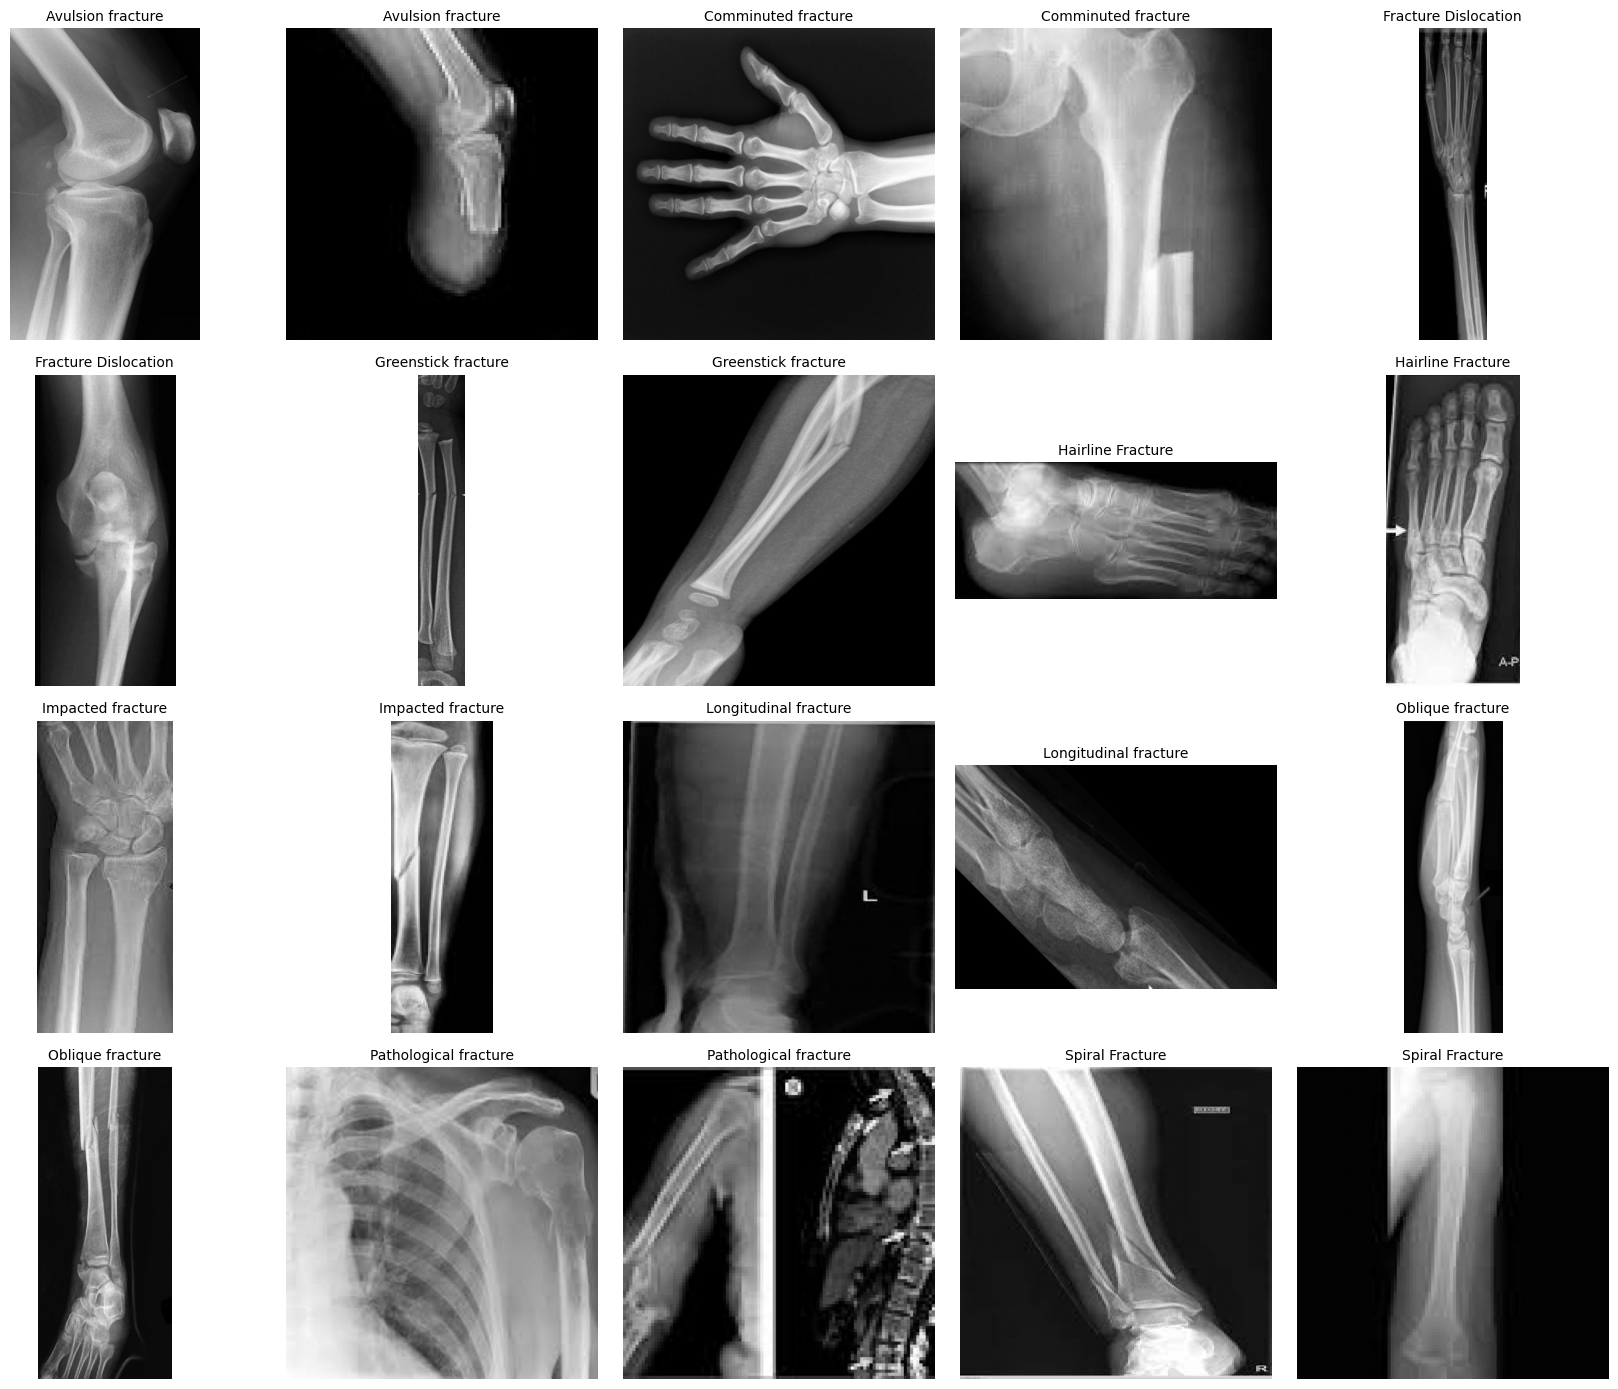

In [7]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(4, 5, figsize=(17, 14))
for i, clase in enumerate(CLASES):
    rutas = df_inv[(df_inv["clase"] == clase) & df_inv["ok"] & (df_inv["particion"] == "train")]["ruta"].values
    for j, ruta in enumerate(rng.choice(rutas, size=2, replace=False)):   # 2 ejemplos al azar por clase
        ax = axes.ravel()[2 * i + j]
        ax.imshow(Image.open(ruta).convert("L"), cmap="gray")
        ax.set_title(clase, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.savefig("images/ejemplos_por_clase.png", dpi=120, bbox_inches="tight"); plt.show()

> **Interpretación (completar después de ejecutar)**

### 2.3 Tamaños y modos de color

Un MLP recibe un vector de largo fijo, así que todas las imágenes deben llevarse al mismo tamaño. Aquí se revisa cuánto varían los tamaños originales y en qué modo de color vienen (RGB = color, L = escala de grises).

Modos de color: {'RGB': 1129}
Tamaños distintos: 642
Ancho: 58 a 640 px (mediana 443)
Alto : 77 a 640 px (mediana 640)


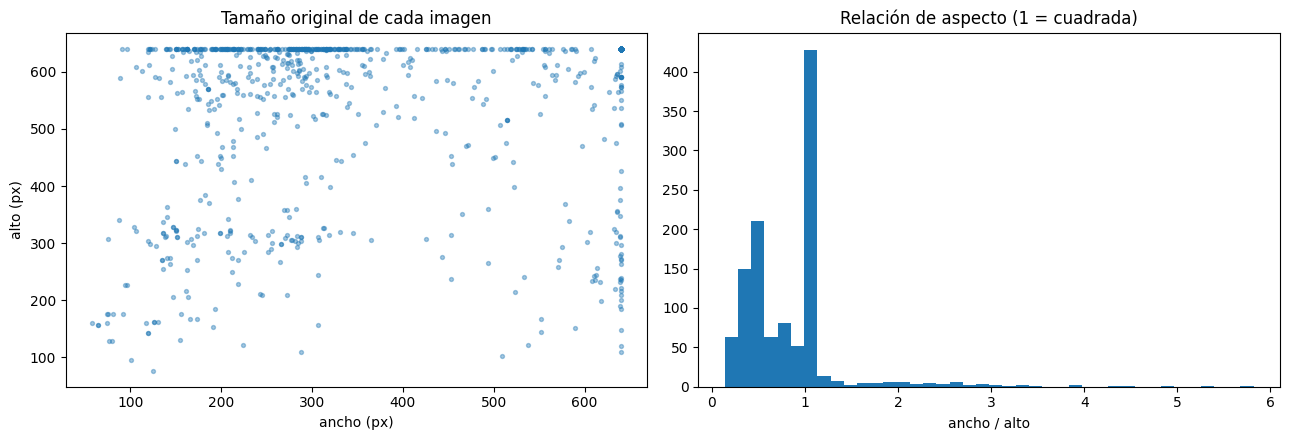

In [8]:
ok = df_inv[df_inv["ok"]]
print("Modos de color:", ok["modo"].value_counts().to_dict())
print(f"Tamaños distintos: {ok.groupby(['ancho', 'alto']).ngroups}")
print(f"Ancho: {ok['ancho'].min():.0f} a {ok['ancho'].max():.0f} px (mediana {ok['ancho'].median():.0f})")
print(f"Alto : {ok['alto'].min():.0f} a {ok['alto'].max():.0f} px (mediana {ok['alto'].median():.0f})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(ok["ancho"], ok["alto"], s=8, alpha=0.4)
ax[0].set_xlabel("ancho (px)"); ax[0].set_ylabel("alto (px)"); ax[0].set_title("Tamaño original de cada imagen")
ax[1].hist(ok["ancho"] / ok["alto"], bins=40)
ax[1].set_xlabel("ancho / alto"); ax[1].set_title("Relación de aspecto (1 = cuadrada)")
plt.tight_layout(); plt.savefig("images/tamanos_originales.png", dpi=150); plt.show()

> **Interpretación (completar después de ejecutar)**

### 2.4 Duplicados y posible fuga de información

Si una misma imagen aparece en entrenamiento y en test, el modelo sería evaluado con algo que ya vio (fuga de información) y las métricas quedarían infladas. Se usan los hash calculados en el inventario: dos archivos con el mismo hash son idénticos.

In [9]:
ok = df_inv[df_inv["ok"]]
print("Duplicados exactos dentro de una misma partición:", int(ok.duplicated(["particion", "hash"]).sum()))
print("Duplicados con etiquetas contradictorias:", int((ok.groupby("hash")["clase"].nunique() > 1).sum()))
h_train = set(ok[ok["particion"] == "train"]["hash"])
h_test = set(ok[ok["particion"] == "test"]["hash"])
print("Imágenes idénticas presentes en train y en test (fuga):", len(h_train & h_test))

Duplicados exactos dentro de una misma partición: 3
Duplicados con etiquetas contradictorias: 0
Imágenes idénticas presentes en train y en test (fuga): 0


> Según la salida del bloque de código anterior, se encontraron 3 imágenes duplicadas dentro de una misma partición (en Train). Ninguna aparece con dos etiquetas distintas, y ninguna imagen de test está repetida en train, por lo que no hay fuga de información entre entrenamiento y prueba.
>
> En base a lo encontrado, se decide conservar una sola copia de cada duplicado, para que ninguna imagen pese el doble durante el entrenamiento; así, las 989 imágenes de Train quedan en 986.
>
> Consideraciones de limitaciones: este control solo detecta copias idénticas; una misma radiografía rotada o recortada no se detectaría.

### 2.5 Brillo y contraste

Las radiografías pueden variar mucho en exposición. Se compara el brillo medio (promedio de los píxeles) y el contraste (desviación estándar de los píxeles) entre clases, sobre una muestra de entrenamiento.

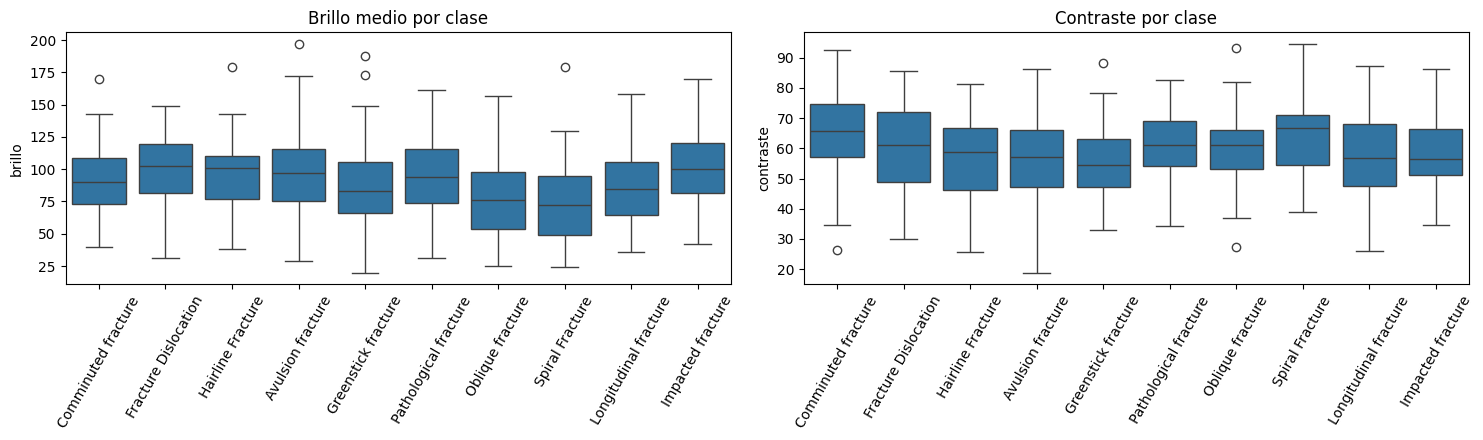

Imágenes con brillo atípico (regla 1,5·IQR): 4 de 600


In [10]:
muestra = df_inv[df_inv["ok"] & (df_inv["particion"] == "train")].sample(frac=1, random_state=SEED) \
            .groupby("clase").head(60).copy()
pix = [np.asarray(Image.open(r).convert("L"), dtype=np.float32) for r in muestra["ruta"]]
muestra["brillo"] = [p.mean() for p in pix]
muestra["contraste"] = [p.std() for p in pix]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=muestra, x="clase", y="brillo", ax=ax[0]); ax[0].set_title("Brillo medio por clase")
sns.boxplot(data=muestra, x="clase", y="contraste", ax=ax[1]); ax[1].set_title("Contraste por clase")
for a in ax:
    a.tick_params(axis="x", rotation=60); a.set_xlabel("")
plt.tight_layout(); plt.savefig("images/brillo_contraste.png", dpi=150); plt.show()

q1, q3 = muestra["brillo"].quantile([0.25, 0.75]); iqr = q3 - q1
atipicas = ((muestra["brillo"] < q1 - 1.5 * iqr) | (muestra["brillo"] > q3 + 1.5 * iqr)).sum()
print(f"Imágenes con brillo atípico (regla 1,5·IQR): {atipicas} de {len(muestra)}")

> **Interpretación (completar después de ejecutar)**

### 2.6 Dificultades esperadas para un MLP

- **Pérdida de la estructura espacial:** el MLP aplana la imagen en un vector y trata cada píxel como una variable independiente; no sabe qué píxeles son vecinos. Las diferencias entre tipos de fractura (la dirección de una línea, si el hueso está fragmentado) son justamente patrones espaciales.
- **Detalles finos:** una fisura (hairline) es una línea muy delgada que puede desaparecer al reducir la resolución.
- **Pocas imágenes para muchas clases:** unas 100 imágenes por clase en entrenamiento; con miles de entradas por imagen, el riesgo de sobreajuste es alto.
- **Variabilidad:** distintas zonas del cuerpo, encuadres y exposiciones dentro de una misma clase.

## 3. Particiones y preprocesamiento

- **Test:** se usan las imágenes de las carpetas Test que entrega el dataset, sin tocarlas hasta la evaluación final.
- **Validación:** se separa un 20% de las imágenes de Train, de forma aleatoria y estratificada (cada clase conserva su proporción). Se usa para comparar configuraciones y elegir el modelo.
- **Entrenamiento:** el 80% restante de Train.
- Se excluyen archivos dañados, duplicados exactos e imágenes de train idénticas a alguna de test.

Las imágenes se cargan como arreglos de NumPy en vez de usar ImageDataGenerator. Así se controla la partición estratificada y se puede cambiar el batch size y la resolución en cada experimento sin reconstruir generadores.

In [11]:
VAL_SIZE = 0.20

base = df_inv[df_inv["ok"]].drop_duplicates(["particion", "hash"], keep="first")
test_df = base[base["particion"] == "test"]
resto = base[(base["particion"] == "train") & ~base["hash"].isin(set(test_df["hash"]))]
train_df, val_df = train_test_split(resto, test_size=VAL_SIZE, stratify=resto["clase"], random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

resumen = pd.DataFrame({"train": train_df["clase"].value_counts(),
                        "validación": val_df["clase"].value_counts(),
                        "test": test_df["clase"].value_counts()}).fillna(0).astype(int)
resumen.loc["TOTAL"] = resumen.sum()
display(resumen)
print("Proporción de cada clase en cada partición:")
display((resumen.drop("TOTAL") / resumen.drop("TOTAL").sum()).round(3))

,train,validación,test
clase,,,
Avulsion fracture,86,22,14
Comminuted fracture,107,27,14
Fracture Dislocation,109,27,19
Greenstick fracture,84,21,16
Hairline Fracture,81,20,10
Impacted fracture,60,15,9
Longitudinal fracture,54,14,12
Oblique fracture,55,14,16
Pathological fracture,93,23,18


Proporción de cada clase en cada partición:


,train,validación,test
clase,,,
Avulsion fracture,0.109,0.111,0.100
Comminuted fracture,0.136,0.136,0.100
Fracture Dislocation,0.138,0.136,0.136
Greenstick fracture,0.107,0.106,0.114
Hairline Fracture,0.103,0.101,0.071
Impacted fracture,0.076,0.076,0.064
Longitudinal fracture,0.069,0.071,0.086
Oblique fracture,0.070,0.071,0.114
Pathological fracture,0.118,0.116,0.129


> De las 989 imágenes de Train se eliminaron 3 duplicados exactos (sección 2.4). Las 986 restantes se dividieron de forma estratificada en 788 de entrenamiento (80%) y 198 de validación (20%), y las 140 imágenes de Test se mantienen intactas para la evaluación final. La tabla de proporciones confirma que cada clase tiene un peso parecido en las tres particiones, gracias a la estratificación. Como test tiene solo unas 14 imágenes por clase, un solo error cambia el recall de esa clase en unos 7 puntos porcentuales, así que sus métricas deben leerse con cautela.

### 3.1 Codificación de etiquetas

Cada clase se convierte en un número (0 a 9) y luego en un vector one-hot: un vector de 10 posiciones con un 1 en la posición de su clase. Es el formato que espera la capa de salida softmax con entropía cruzada categórica.

In [12]:
indice = {clase: i for i, clase in enumerate(CLASES)}
y_train = train_df["clase"].map(indice).values
y_val   = val_df["clase"].map(indice).values
y_test  = test_df["clase"].map(indice).values

Y_train = keras.utils.to_categorical(y_train, N_CLASES)
Y_val   = keras.utils.to_categorical(y_val, N_CLASES)
Y_test  = keras.utils.to_categorical(y_test, N_CLASES)

display(pd.DataFrame({"índice": range(N_CLASES), "clase": CLASES}))
print("Ejemplo:", train_df["clase"][0], "→ índice", y_train[0], "→ one-hot", Y_train[0].astype(int))

,índice,clase
0,0,Avulsion fracture
1,1,Comminuted fracture
2,2,Fracture Dislocation
3,3,Greenstick fracture
4,4,Hairline Fracture
5,5,Impacted fracture
6,6,Longitudinal fracture
7,7,Oblique fracture
8,8,Pathological fracture
9,9,Spiral Fracture


Ejemplo: Hairline Fracture → índice 4 → one-hot [0 0 0 0 1 0 0 0 0 0]


### 3.2 Preprocesamiento

Para cada imagen:
1. **Escala de grises:** 1 valor por píxel (ver sección 2.3).
2. **Redimensionar** a un tamaño cuadrado fijo.
3. **Normalizar** dividiendo por 255: los píxeles pasan de 0–255 a 0–1. Las redes aprenden de forma más estable con entradas en rangos pequeños. Como 255 es un valor fijo, no depende de los datos y no genera fuga de información.
4. **Aplanar** la imagen en un vector, que es la entrada que admite un MLP.

Como la resolución se elige experimentalmente (sección 5.2), se preparan los datos en tres tamaños: 32×32, 64×64 y 128×128.

In [13]:
TAMANOS = [32, 64, 128]

def cargar_imagenes(rutas, tamano):
    """Lee cada imagen, la pasa a escala de grises y la redimensiona a tamano x tamano."""
    X = np.empty((len(rutas), tamano, tamano), dtype=np.uint8)
    for i, ruta in enumerate(rutas):
        with Image.open(ruta) as im:
            X[i] = np.asarray(im.convert("L").resize((tamano, tamano), Image.BILINEAR))
    return X

DATOS = {}
for t in TAMANOS:
    imagenes = [cargar_imagenes(d["ruta"].values, t) for d in (train_df, val_df, test_df)]
    vectores = [a.reshape(len(a), -1).astype("float32") / 255.0 for a in imagenes]   # aplanar y normalizar
    DATOS[t] = {"img": imagenes, "X": vectores}
    print(f"{t}x{t}: {vectores[0].shape[1]:>6} entradas por imagen | "
          f"train {vectores[0].shape} | val {vectores[1].shape} | test {vectores[2].shape}")

32x32:   1024 entradas por imagen | train (788, 1024) | val (198, 1024) | test (140, 1024)
64x64:   4096 entradas por imagen | train (788, 4096) | val (198, 4096) | test (140, 4096)
128x128:  16384 entradas por imagen | train (788, 16384) | val (198, 16384) | test (140, 16384)


> **Qué hace el bloque anterior:** la función cargar_imagenes abre cada radiografía, la convierte a escala de grises (convert("L")) y la redimensiona a un tamaño cuadrado (resize). Luego, para cada resolución (32×32, 64×64 y 128×128), cada imagen se aplana en un vector (reshape) y se normaliza dividiendo por 255, de modo que los píxeles quedan entre 0 y 1. Los resultados se guardan en el diccionario DATOS, para no volver a leer las imágenes desde el disco en cada experimento.
>
> **Qué muestra la salida:** cada fila indica cuántas entradas recibe el MLP según la resolución y el tamaño de cada partición, con la forma (cantidad de imágenes, entradas por imagen):
>
> | Resolución | Entradas por imagen | Train | Validación | Test |
> |---|---|---|---|---|
> | 32×32 | 1.024 | 788 | 198 | 140 |
> | 64×64 | 4.096 | 788 | 198 | 140 |
> | 128×128 | 16.384 | 788 | 198 | 140 |
>
> **Por qué importa:** la cantidad de imágenes es la misma en las tres resoluciones; lo único que cambia es el largo del vector de entrada. Cada vez que el lado de la imagen se duplica, las entradas se multiplican por 4, y con ellas los pesos de la primera capa del MLP (entradas × neuronas). Con solo 788 imágenes de entrenamiento (unas 79 por clase), un vector más largo conserva más detalle de la fractura, pero también da al modelo más parámetros con los que memorizar los datos (sobreajuste). Este equilibrio es el que se mide experimentalmente en la sección 5.2.

### 3.3 Ejemplo antes y después del preprocesamiento

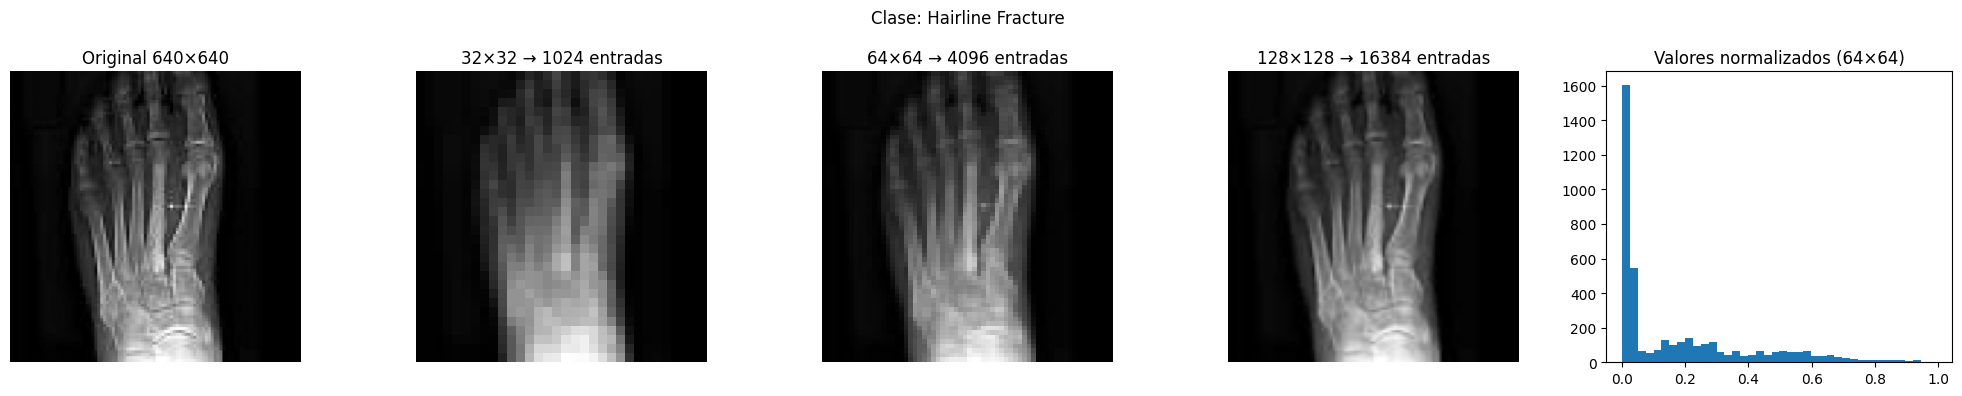

In [14]:
i = 0
original = Image.open(train_df["ruta"][i]).convert("L")
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(original, cmap="gray"); ax[0].set_title(f"Original {original.size[0]}×{original.size[1]}")
for a, t in zip(ax[1:4], TAMANOS):
    a.imshow(DATOS[t]["img"][0][i], cmap="gray"); a.set_title(f"{t}×{t} → {t*t} entradas")
for a in ax[:4]:
    a.axis("off")
ax[4].hist(DATOS[64]["X"][0][i], bins=40); ax[4].set_title("Valores normalizados (64×64)")
plt.suptitle(f"Clase: {train_df['clase'][i]}")
plt.tight_layout(); plt.savefig("images/antes_despues_preprocesamiento.png", dpi=130); plt.show()

> **Interpretación (completar después de ejecutar)**

### 3.4 Aislamiento del test

Desde este punto, X_test / y_test no se usan para entrenar, comparar ni elegir ninguna configuración. Todas las decisiones de la sección 5 se toman con validación. El test se evalúa una sola vez, en la sección 6, con la configuración ya cerrada.

## 4. Métricas y herramientas de experimentación

### 4.1 Métricas: qué significan y cómo se calculan

Las métricas se calculan para cada tipo de fractura por separado. Por ejemplo, para la clase fractura espiral: VP = fracturas espirales que el modelo predijo como espirales; FP = fracturas de otros tipos que el modelo predijo como espirales; FN = fracturas espirales que el modelo predijo como otro tipo. Luego se repite el cálculo con cada una de las 10 clases.

| Métrica | Fórmula | Qué responde (ejemplo con fractura espiral) |
|---|---|---|
| **Accuracy** | aciertos / total | ¿Qué proporción de todas las radiografías se clasificó bien? Engañosa con clases desbalanceadas. |
| **Precision** | VP / (VP + FP) | De las que el modelo dijo "fractura espiral", ¿cuántas lo eran? |
| **Recall** | VP / (VP + FN) | De las fracturas espirales reales, ¿cuántas encontró el modelo? |
| **F1** | 2·P·R / (P + R) | Media armónica: solo es alta si precision **y** recall lo son. |

- **Promedio macro:** se calcula la métrica en cada clase y se promedian las 10 sin ponderar, de modo que cada tipo de fractura pesa lo mismo aunque tenga menos imágenes. Por el desbalance entre clases observado en la sección 2.1, la métrica de selección es el F1 macro.
- **Entropía cruzada de validación (log-loss):** es la misma entropía cruzada que usa Keras como función de pérdida, calculada igual para todos los experimentos. Se usa como desempate porque la val_loss de Keras no es comparable entre experimentos entrenados con distintas funciones de pérdida.
- **En este caso,** el recall es especialmente relevante: no reconocer un tipo de fractura (por ejemplo, una fractura patológica, asociada a enfermedades del hueso) es más grave que una falsa alarma. **[COMPLETAR: qué clase o error consideramos más crítico y por qué].**

### 4.2 Herramientas del experimento

En vez de copiar el modelo cada vez que se prueba algo, se usan dos funciones:
- construir_mlp(...) arma el MLP a partir de parámetros: capas y neuronas, activación, dropout, L2, batch normalization, optimizador, learning rate y función de pérdida.
- ejecutar_experimento(...) entrena un modelo con una configuración, lo evalúa en validación y guarda los resultados en una tabla.

Las arquitecturas se escriben como CAPAS x NEURONAS: 4x10 significa 4 capas ocultas de 10 neuronas cada una.

In [15]:
def arq(texto):
    """'4x10' → 4 capas ocultas de 10 neuronas; '8-4' → una capa de 8 neuronas seguida de una de 4."""
    if "-" in texto:
        return tuple(int(n) for n in texto.split("-"))
    n_capas, n_neuronas = (int(v) for v in texto.lower().split("x"))
    return (n_neuronas,) * n_capas

# Configuración de partida (baseline). Cada experimento cambia uno de estos valores.
BASELINE = dict(
    img_size=64,              # resolución de entrada (64x64)
    capas=arq("4x10"),        # 4 capas ocultas de 10 neuronas
    activacion="relu",
    inicializador="glorot_uniform",   # inicialización de pesos (Glorot/Xavier, valor por defecto de Keras)
    dropout=0.0,
    l2=0.0,
    batch_norm=False,
    optimizador="adam",
    learning_rate=1e-3,
    perdida="cce",            # entropía cruzada categórica
    batch_size=32,
    max_epocas=100,
    early_stopping=True,
)
PACIENCIA = 8          # épocas sin mejorar val_loss antes de detener el entrenamiento
UMBRAL_GAP = 0.05      # diferencia train-val de accuracy desde la que se diagnostica sobreajuste
MIN_MEJORA = 0.005     # mejora mínima de F1 macro para considerar que un cambio ayuda

def crear_optimizador(nombre, lr):
    return {"adam": lambda: keras.optimizers.Adam(lr),
            "sgd": lambda: keras.optimizers.SGD(lr),
            "sgd_momentum": lambda: keras.optimizers.SGD(lr, momentum=0.9),
            "rmsprop": lambda: keras.optimizers.RMSprop(lr)}[nombre]()

def crear_perdida(nombre):
    return {"cce": lambda: keras.losses.CategoricalCrossentropy(),
            "mse": lambda: keras.losses.MeanSquaredError(),
            "focal": lambda: keras.losses.CategoricalFocalCrossentropy(gamma=2.0)}[nombre]()

def construir_mlp(n_entradas, capas, activacion, inicializador, dropout, l2, batch_norm, optimizador,
                  learning_rate, perdida, seed=None, **_):
    reiniciar_semillas(seed)                  # misma arquitectura → mismos pesos iniciales
    reg = regularizers.l2(l2) if l2 > 0 else None
    entrada = keras.Input(shape=(n_entradas,))
    x = entrada
    for n in capas:                           # capas ocultas
        x = layers.Dense(n, kernel_regularizer=reg, kernel_initializer=inicializador)(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation(activacion)(x)
        if dropout > 0:
            x = layers.Dropout(dropout, seed=SEED if seed is None else seed)(x)
    salida = layers.Dense(N_CLASES, activation="softmax")(x)   # 10 probabilidades que suman 1
    modelo = keras.Model(entrada, salida)
    modelo.compile(optimizer=crear_optimizador(optimizador, learning_rate),
                   loss=crear_perdida(perdida), metrics=["accuracy"])
    return modelo

RESULTADOS, HISTORIALES = [], {}

def ejecutar_experimento(id_exp, grupo, cambio, verbose=0, guardar=True, seed=None, **cambios):
    cfg = {**BASELINE, **cambios}
    X_tr, X_va, _ = DATOS[cfg["img_size"]]["X"]
    modelo = construir_mlp(X_tr.shape[1], **cfg, seed=seed)
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=PACIENCIA,
                                               restore_best_weights=True)] if cfg["early_stopping"] else []
    t0 = time.time()
    h = modelo.fit(X_tr, Y_train, validation_data=(X_va, Y_val), epochs=cfg["max_epocas"],
                   batch_size=cfg["batch_size"], shuffle=True, callbacks=callbacks, verbose=verbose)
    duracion = time.time() - t0
    p_val = modelo.predict(X_va, batch_size=1024, verbose=0)
    p_tr = modelo.predict(X_tr, batch_size=1024, verbose=0)
    yv, yt = p_val.argmax(1), p_tr.argmax(1)
    acc_tr, acc_val = accuracy_score(y_train, yt), accuracy_score(y_val, yv)
    capas = cfg["capas"]
    fila = dict(
        id=id_exp, grupo=grupo, cambio=cambio, img_size=cfg["img_size"],
        arquitectura=f"{len(capas)}x{capas[0]}" if len(set(capas)) == 1 else "-".join(map(str, capas)),
        activacion=cfg["activacion"], inicializador=cfg["inicializador"], perdida=cfg["perdida"], optimizador=cfg["optimizador"],
        lr=cfg["learning_rate"], batch=cfg["batch_size"],
        regularizacion=((f"dropout={cfg['dropout']} " if cfg["dropout"] else "") +
                        (f"L2={cfg['l2']} " if cfg["l2"] else "") + ("BN" if cfg["batch_norm"] else "")) or "ninguna",
        epocas_ejecutadas=len(h.history["loss"]), mejor_epoca=int(np.argmin(h.history["val_loss"]) + 1),
        val_logloss=log_loss(y_val, p_val, labels=range(N_CLASES)),
        val_accuracy=acc_val,
        val_precision=precision_score(y_val, yv, average="macro", zero_division=0),
        val_recall=recall_score(y_val, yv, average="macro", zero_division=0),
        val_f1=f1_score(y_val, yv, average="macro"),
        train_accuracy=acc_tr, gap_train_val=acc_tr - acc_val,
        parametros=modelo.count_params(), segundos=round(duracion, 1))
    if guardar:
        RESULTADOS[:] = [r for r in RESULTADOS if r["id"] != id_exp] + [fila]
        HISTORIALES[id_exp] = h.history
    print(f"{id_exp:<9} {cambio:<30} F1 val={fila['val_f1']:.4f}  acc val={acc_val:.4f}  "
          f"gap={fila['gap_train_val']:+.4f}  épocas={fila['epocas_ejecutadas']} ({duracion:.0f}s)")
    return modelo, fila

COLS_TABLA = ["id", "cambio", "epocas_ejecutadas", "mejor_epoca", "val_logloss", "val_accuracy",
              "val_precision", "val_recall", "val_f1", "gap_train_val", "parametros"]

def tabla(ids):
    """Tabla comparativa de un grupo de experimentos (mejores valores en verde)."""
    df = pd.DataFrame(RESULTADOS).set_index("id").loc[ids].reset_index()
    return df[COLS_TABLA].style.format({c: "{:.4f}" for c in COLS_TABLA[4:10]}) \
        .highlight_max(subset=["val_f1", "val_accuracy"], color="#c6efce") \
        .highlight_min(subset=["val_logloss"], color="#c6efce")

def graficar(ids, titulo, archivo):
    """Curvas de validación (pérdida y accuracy) por época de varios experimentos."""
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for i in ids:
        h = HISTORIALES[i]; etiqueta = next(r["cambio"] for r in RESULTADOS if r["id"] == i)
        ax[0].plot(h["val_loss"], label=f"{i}: {etiqueta}")
        ax[1].plot(h["val_accuracy"], label=f"{i}: {etiqueta}")
    ax[0].set_title(f"{titulo} — pérdida en validación"); ax[1].set_title(f"{titulo} — accuracy en validación")
    for a in ax:
        a.set_xlabel("época"); a.legend(fontsize=8); a.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f"images/{archivo}.png", dpi=150, bbox_inches="tight"); plt.show()

def curvas_train_val(id_exp, archivo=None):
    """Curvas de entrenamiento vs validación de un experimento, marcando la mejor época."""
    h = HISTORIALES[id_exp]; mejor = int(np.argmin(h["val_loss"]))
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for a, m in zip(ax, ["loss", "accuracy"]):
        a.plot(h[m], label=f"train {m}"); a.plot(h[f"val_{m}"], label=f"val {m}")
        a.axvline(mejor, ls="--", c="gray", label=f"mejor época ({mejor + 1})")
        a.set_title(f"{id_exp} — {m}"); a.set_xlabel("época"); a.legend(); a.grid(alpha=.3)
    plt.tight_layout()
    if archivo:
        plt.savefig(f"images/{archivo}.png", dpi=150, bbox_inches="tight")
    plt.show()

def diagnosticar(id_exp):
    """Diagnóstico automático: sobreajuste, subajuste o ajuste razonable."""
    r = next(r for r in RESULTADOS if r["id"] == id_exp)
    if r["gap_train_val"] > UMBRAL_GAP:
        d = "sobreajuste: el modelo rinde claramente mejor en train que en validación"
    elif r["train_accuracy"] < 0.5:
        d = "subajuste: el modelo no logra aprender ni siquiera los datos de entrenamiento"
    else:
        d = "ajuste razonable"
    print(f"{id_exp}: acc train={r['train_accuracy']:.4f} | acc val={r['val_accuracy']:.4f} | "
          f"gap={r['gap_train_val']:+.4f} | mejor época {r['mejor_epoca']} de {r['epocas_ejecutadas']} → {d}")

### 4.3 Protocolo experimental

| Aspecto | Decisión |
|---|---|
| Diseño | Un parámetro a la vez. Primero se fija la resolución (sección 5.2) y después la arquitectura (sección 5.3); esa configuración queda como referencia (REF) y cada experimento posterior cambia un único parámetro respecto de ella. |
| Qué se mantiene igual | Partición train/validación, semilla (reiniciada antes de cada modelo), preprocesamiento, early stopping (paciencia 8, restaurando los mejores pesos) y máximo de 100 épocas. |
| Métrica de selección | F1 macro en validación; desempate por menor entropía cruzada de validación, menor gap train-validación y menor complejidad. |
| Mejor época | La de menor pérdida en validación (early stopping restaura sus pesos). |
| Cuándo se adopta un cambio | Solo si mejora el F1 macro de validación en al menos 0,005 respecto de la referencia; diferencias menores se consideran ruido (ver sección 5.13). |
| Test | No se usa hasta la sección 6. |
| Orden de los experimentos | Sigue los pasos para mejorar la generalización: si el error de entrenamiento es alto (underfitting), se aumenta la capacidad de la red (resolución y arquitectura); si luego aparece una diferencia grande entre entrenamiento y validación (overfitting), se ajustan hiperparámetros que no aumentan la capacidad (learning rate, batch size, funciones, regularización y optimizador). |

**Secuencia:** baseline → resolución → arquitectura → learning rate → batch size → épocas → → activación → inicialización de pesos → pérdida → regularización → optimizador → tabla consolidada → modelo final → evaluación única en test.

## 5. Experimentos controlados y selección del modelo

### 5.1 Baseline (E0)

| Parámetro | Valor inicial | Motivo |
|---|---|---|
| Resolución | 64×64, escala de grises → 4.096 entradas | Punto intermedio entre conservar detalle y controlar el número de parámetros; se compara en la sección 5.2 |
| Capas ocultas | 4 capas de 10 neuronas ("4x10") | Arquitectura con la que trabajamos en el proyecto anterior; como no existe una regla exacta para decidir capas y neuronas, se prueban otras combinaciones en la sección 5.3 |
| Activación oculta | ReLU | Punto de partida habitual; se compara en la sección 5.7 |
| Inicialización de pesos | Glorot (Xavier) | Valor por defecto de Keras; se compara con He en la sección 5.7.1 |
| Salida | Softmax con 10 neuronas | 10 clases excluyentes → entrega 10 probabilidades que suman 1 |
| Pérdida | Entropía cruzada categórica | Pérdida natural para softmax multiclase; se compara en la sección 5.8 |
| Optimizador / learning rate | Adam, 0,001 | Valores por defecto habituales; se comparan en las secciones 5.10 y 5.4 |
| Batch size | 32 | Se compara en la sección 5.5 |
| Épocas | Máximo 100 con early stopping | Se analiza en la sección 5.6 |
| Regularización | Ninguna | Permite medir después, en la sección 5.9, el efecto de dropout, L2 y batch normalization |

**Hipótesis:** con solo 10 neuronas por capa frente a 4.096 entradas, la primera capa obliga a resumir toda la imagen en 10 valores; se espera un desempeño limitado.

E0        Baseline (64x64, 4x10)         F1 val=0.0681  acc val=0.1515  gap=+0.0185  épocas=45 (16s)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,232 (485.29 KB)

 Trainable params: 41,410 (161.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,822 (323.53 KB)

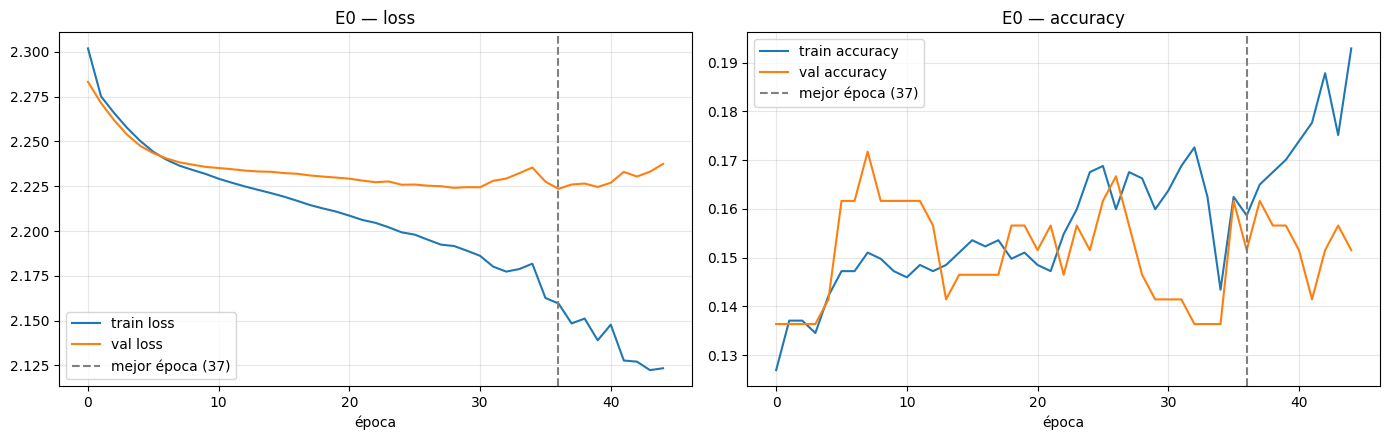

E0: acc train=0.1701 | acc val=0.1515 | gap=+0.0185 | mejor época 37 de 45 → subajuste: el modelo no logra aprender ni siquiera los datos de entrenamiento


In [16]:
modelo_e0, _ = ejecutar_experimento("E0", "baseline", "Baseline (64x64, 4x10)")
modelo_e0.summary()
curvas_train_val("E0", "curvas_E0_baseline")
diagnosticar("E0")

> **Interpretación (completar después de ejecutar)**

### 5.2 Experimento de resolución de entrada

Solo cambia el tamaño al que se redimensionan las imágenes: 32×32 y 128×128, frente a 64×64 del baseline. Todo lo demás queda igual.

| Resolución | Entradas | Parámetros de la primera capa (con 10 neuronas) |
|---|---|---|
| 32×32 | 1.024 | 10.250 |
| 64×64 | 4.096 | 40.970 |
| 128×128 | 16.384 | 163.850 |

**Hipótesis:** 32×32 pierde detalles de la fractura (subajuste por falta de información); 128×128 conserva más detalle, pero cuadruplica las entradas y, con pocas imágenes, puede sobreajustar. Se espera que un tamaño intermedio sea el mejor compromiso, pero la decisión la toma el F1 de validación.

RES_32    resolución 32x32               F1 val=0.0638  acc val=0.1465  gap=+0.0325  épocas=34 (9s)
RES_128   resolución 128x128             F1 val=0.0456  acc val=0.1515  gap=+0.0223  épocas=33 (13s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,RES_32,resolución 32x32,34,26,2.2335,0.1465,0.0433,0.1222,0.0638,0.0325,10690
1,E0,"Baseline (64x64, 4x10)",45,37,2.2235,0.1515,0.0464,0.1319,0.0681,0.0185,41410
2,RES_128,resolución 128x128,33,25,2.2488,0.1515,0.0338,0.1200,0.0456,0.0223,164290


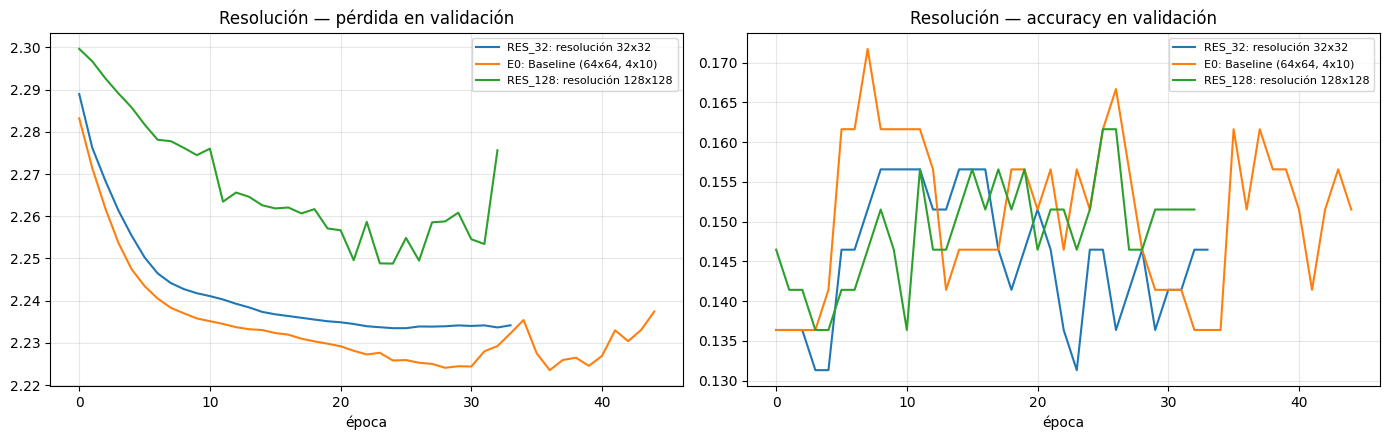

In [17]:
for t in [32, 128]:
    ejecutar_experimento(f"RES_{t}", "resolucion", f"resolución {t}x{t}", img_size=t)
IDS_RES = ["RES_32", "E0", "RES_128"]
display(tabla(IDS_RES))
graficar(IDS_RES, "Resolución", "exp_resolucion")

> **Interpretación (completar después de ejecutar)**

#### 5.2.1 Resolución de referencia

Se fija la resolución con mejor F1 macro en validación (desempate: menor log-loss). Desde aquí, todos los experimentos usan esa resolución.

In [18]:
res_df = pd.DataFrame(RESULTADOS).set_index("id").loc[IDS_RES]
mejor_res = res_df.sort_values(["val_f1", "val_logloss"], ascending=[False, True]).iloc[0]
BASELINE["img_size"] = int(mejor_res["img_size"])
REF = mejor_res.name
f1_ref = mejor_res["val_f1"]
print(f"Resolución elegida: {BASELINE['img_size']}x{BASELINE['img_size']} (experimento {REF}, F1 val {f1_ref:.4f})")

Resolución elegida: 64x64 (experimento E0, F1 val 0.0681)


### 5.3 Experimento de arquitectura (capas y neuronas)

Como no existe una fórmula para decidir cuántas capas y neuronas necesita una red (depende de cada problema), probamos varias combinaciones y dejamos que la validación decida. Solo cambia la arquitectura; la resolución es la elegida en la sección 5.2.

Se usa la notación CAPAS x NEURONAS: 4x10 significa 4 capas ocultas de 10 neuronas cada una. Para redes con distinta cantidad de neuronas por capa se usa un guion: 8-4 significa una primera capa de 8 neuronas y una segunda de 4.

| Arquitectura | Qué queríamos ver |
|---|---|
| 4x10 | Punto de partida (baseline) |
| 4x4 | Mismas 4 capas, con menos neuronas |
| 4x30 | Mismas 4 capas, con más neuronas |
| 2x8 | 2 capas de 8 neuronas, como la red que en TensorFlow Playground logra separar el problema de la espiral |
| 8-4 | Forma de "embudo": la segunda capa con menos neuronas que la primera |
| 16-8 | El mismo embudo con el doble de neuronas |
| 2x30 | Menos capas, pero más anchas |
| 2x100 | ¿Y si subimos mucho las neuronas? |

**Hipótesis:** con 4.096 entradas, las capas de pocas neuronas (4 u 8) serán un cuello de botella y el modelo aprenderá poco (underfitting). Al aumentar las neuronas, la red tendrá más capacidad para aprender, pero con riesgo de overfitting, ya que solo hay 788 imágenes de entrenamiento.

A_4x4     arquitectura 4x4               F1 val=0.0618  acc val=0.1667  gap=+0.0072  épocas=81 (19s)
A_2x8     arquitectura 2x8               F1 val=0.0240  acc val=0.1364  gap=+0.0020  épocas=68 (15s)
A_8-4     arquitectura 8-4               F1 val=0.0524  acc val=0.1667  gap=+0.0199  épocas=40 (10s)
A_16-8    arquitectura 16-8              F1 val=0.0309  acc val=0.1364  gap=+0.0299  épocas=64 (16s)
A_2x30    arquitectura 2x30              F1 val=0.1294  acc val=0.1768  gap=+0.0758  épocas=29 (9s)
A_4x30    arquitectura 4x30              F1 val=0.0933  acc val=0.1869  gap=+0.0733  épocas=18 (6s)
A_2x100   arquitectura 2x100             F1 val=0.0976  acc val=0.1818  gap=+0.1075  épocas=17 (8s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,E0,"Baseline (64x64, 4x10)",45,37,2.2235,0.1515,0.0464,0.1319,0.0681,0.0185,41410
1,A_4x4,arquitectura 4x4,81,73,2.2550,0.1667,0.0609,0.1281,0.0618,0.0072,16498
2,A_2x8,arquitectura 2x8,68,60,2.2728,0.1364,0.0136,0.1000,0.0240,0.0020,32938
3,A_8-4,arquitectura 8-4,40,32,2.2674,0.1667,0.0388,0.1222,0.0524,0.0199,32862
4,A_16-8,arquitectura 16-8,64,56,2.2556,0.1364,0.0252,0.1006,0.0309,0.0299,65778
5,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
6,A_4x30,arquitectura 4x30,18,10,2.2053,0.1869,0.0787,0.1434,0.0933,0.0733,126010
7,A_2x100,arquitectura 2x100,17,9,2.2180,0.1818,0.0860,0.1460,0.0976,0.1075,420810


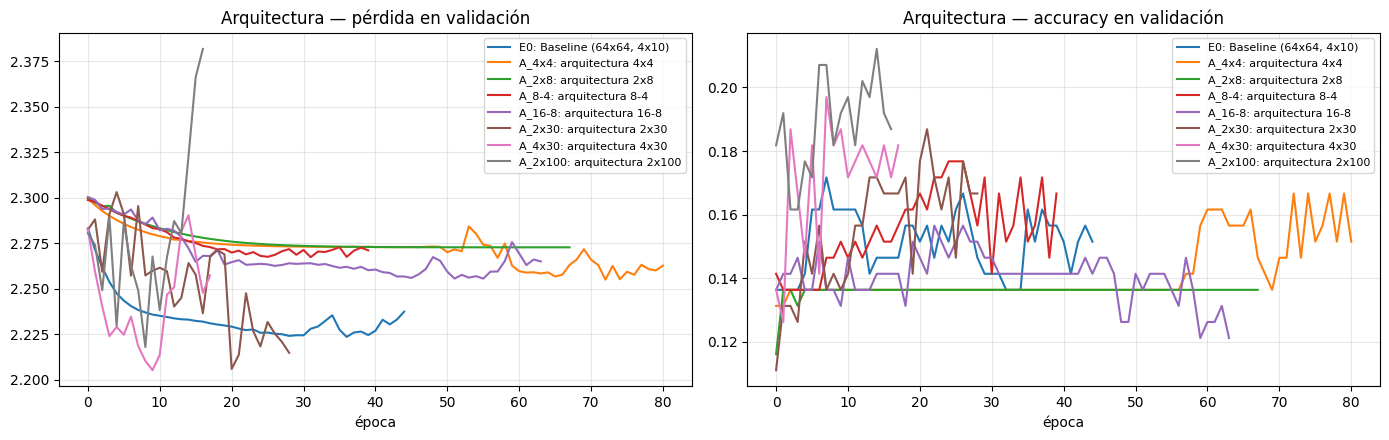

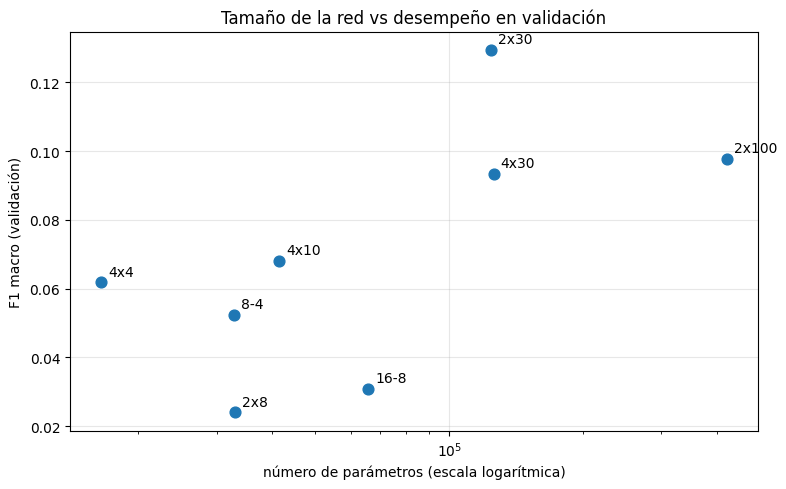

In [19]:
ARQUITECTURAS = ["4x4", "2x8", "8-4", "16-8", "2x30", "4x30", "2x100"]   # capas x neuronas; "8-4" capas de distinto tamaño # se pueden agregar o quitar combinaciones
for a in ARQUITECTURAS:
    ejecutar_experimento(f"A_{a}", "arquitectura", f"arquitectura {a}", capas=arq(a))
IDS_ARQ = [REF] + [f"A_{a}" for a in ARQUITECTURAS]
display(tabla(IDS_ARQ))
graficar(IDS_ARQ, "Arquitectura", "exp_arquitectura")

arq_df = pd.DataFrame(RESULTADOS).set_index("id").loc[IDS_ARQ]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(arq_df["parametros"], arq_df["val_f1"], s=60)
for i, r in arq_df.iterrows():
    ax.annotate(r["arquitectura"], (r["parametros"], r["val_f1"]), textcoords="offset points", xytext=(5, 5))
ax.set_xscale("log"); ax.set_xlabel("número de parámetros (escala logarítmica)"); ax.set_ylabel("F1 macro (validación)")
ax.set_title("Tamaño de la red vs desempeño en validación"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("images/arquitectura_parametros_vs_f1.png", dpi=150); plt.show()

> **Interpretación (completar después de ejecutar)**

#### 5.3.1 Configuración de referencia (REF)

Se fija la arquitectura con mejor F1 macro en validación. Resolución + arquitectura forman la referencia (REF): cada experimento siguiente cambia un solo parámetro respecto de ella.

In [20]:
mejor_arq = arq_df.sort_values(["val_f1", "val_logloss"], ascending=[False, True]).iloc[0]
BASELINE["capas"] = arq(mejor_arq["arquitectura"])
REF = mejor_arq.name
f1_ref = mejor_arq["val_f1"]
print(f"Referencia: {REF} — {BASELINE['img_size']}x{BASELINE['img_size']}, arquitectura {mejor_arq['arquitectura']}, "
      f"F1 val {f1_ref:.4f}")
diagnosticar(REF)

Referencia: A_2x30 — 64x64, arquitectura 2x30, F1 val 0.1294
A_2x30: acc train=0.2525 | acc val=0.1768 | gap=+0.0758 | mejor época 21 de 29 → sobreajuste: el modelo rinde claramente mejor en train que en validación


### 5.4 Experimento de learning rate

Solo cambia la tasa de aprendizaje: 0,01 y 0,0001, frente a 0,001 de la referencia. El learning rate define el tamaño del paso con que se actualizan los pesos en cada iteración.

**Hipótesis:** 0,01 converge rápido pero de forma inestable (curvas ruidosas, puede saltarse un buen mínimo); 0,0001 es estable pero lento y puede necesitar muchas más épocas.

LR_0.01   learning rate 0.01             F1 val=0.0795  acc val=0.1717  gap=+0.0212  épocas=14 (4s)
LR_0.0001 learning rate 0.0001           F1 val=0.1489  acc val=0.2071  gap=+0.1813  épocas=52 (15s)
LR_0.00001 learning rate 1e-05            F1 val=0.1052  acc val=0.2071  gap=+0.0480  épocas=100 (26s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,LR_0.01,learning rate 0.01,14,6,2.2585,0.1717,0.1275,0.1311,0.0795,0.0212,124150
1,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
2,LR_0.0001,learning rate 0.0001,52,44,2.1727,0.2071,0.1355,0.1762,0.1489,0.1813,124150
3,LR_0.00001,learning rate 1e-05,100,100,2.2450,0.2071,0.0764,0.1725,0.1052,0.0480,124150


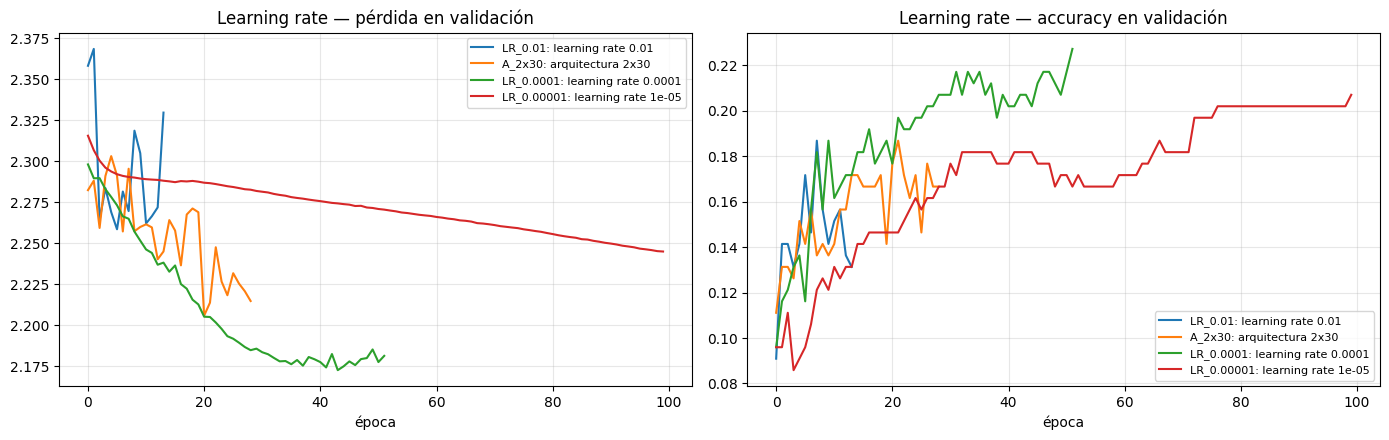

In [21]:
# 0.001 no se entrena de nuevo: es el valor de la referencia (REF), que se incluye en la tabla y el gráfico
for i, lr in zip(["LR_0.01", "LR_0.0001", "LR_0.00001"], [1e-2, 1e-4, 1e-5]):
    ejecutar_experimento(i, "learning_rate", f"learning rate {lr}", learning_rate=lr)
IDS_LR = ["LR_0.01", REF, "LR_0.0001", "LR_0.00001"]   # ordenados de mayor a menor learning rate
display(tabla(IDS_LR))
graficar(IDS_LR, "Learning rate", "exp_learning_rate")

> **Interpretación (completar después de ejecutar)**

### 5.5 Experimento de batch size

Solo cambia el tamaño del lote: 64 y 128, frente a 32 de la referencia. El batch size es la cantidad de imágenes que se procesan antes de cada actualización de pesos.

**Hipótesis:** lotes más grandes dan gradientes más estables pero menos actualizaciones por época; con el mismo learning rate pueden converger más lento o generalizar algo peor.

BS_64     batch size 64                  F1 val=0.1584  acc val=0.2020  gap=+0.0518  épocas=24 (6s)
BS_128    batch size 128                 F1 val=0.1407  acc val=0.2020  gap=+0.0112  épocas=22 (5s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,BS_64,batch size 64,24,16,2.2194,0.2020,0.2341,0.1737,0.1584,0.0518,124150
2,BS_128,batch size 128,22,14,2.2373,0.2020,0.1585,0.1844,0.1407,0.0112,124150


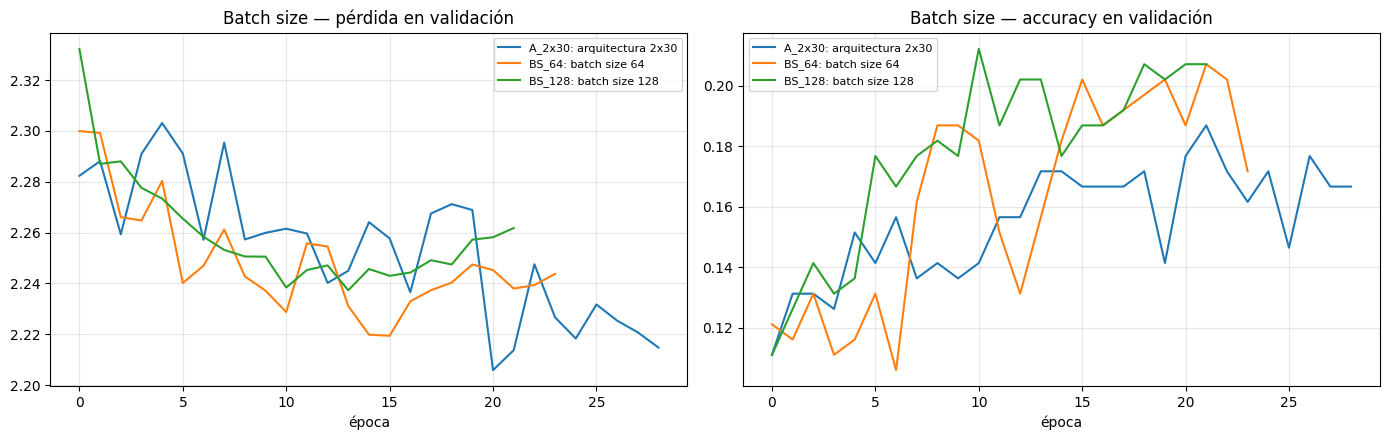

In [22]:
for i, bs in zip(["BS_64", "BS_128"], [64, 128]):
    ejecutar_experimento(i, "batch_size", f"batch size {bs}", batch_size=bs)
display(tabla([REF, "BS_64", "BS_128"]))
graficar([REF, "BS_64", "BS_128"], "Batch size", "exp_batch_size")

> **Interpretación (completar después de ejecutar)**

### 5.6 Análisis de épocas

Se entrena la referencia sin early stopping durante 60 épocas fijas, para observar qué ocurre si se sigue entrenando después de la mejor época.

EP_60     60 épocas sin early stopping   F1 val=0.1830  acc val=0.2071  gap=+0.2028  épocas=60 (16s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,EP_60,60 épocas sin early stopping,60,21,2.4133,0.2071,0.2261,0.1907,0.1830,0.2028,124150


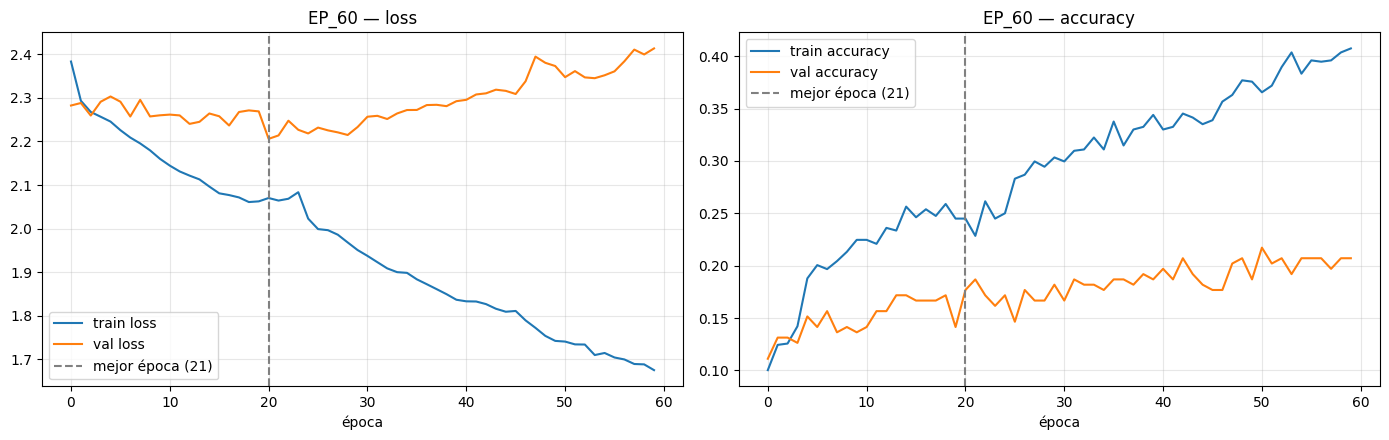

Mejor pérdida de validación en la época 21 (2.2059); en la época 60: 2.4133
Gap de accuracy train-val en la mejor época: +0.0682 | en la época 60: +0.2003


In [23]:
ejecutar_experimento("EP_60", "epocas", "60 épocas sin early stopping", early_stopping=False, max_epocas=60)
display(tabla([REF, "EP_60"]))
curvas_train_val("EP_60", "curvas_sin_early_stopping")
h = HISTORIALES["EP_60"]; mejor = int(np.argmin(h["val_loss"]))
print(f"Mejor pérdida de validación en la época {mejor + 1} ({h['val_loss'][mejor]:.4f}); "
      f"en la época 60: {h['val_loss'][-1]:.4f}")
print(f"Gap de accuracy train-val en la mejor época: {h['accuracy'][mejor] - h['val_accuracy'][mejor]:+.4f} | "
      f"en la época 60: {h['accuracy'][-1] - h['val_accuracy'][-1]:+.4f}")

> **Interpretación (completar después de ejecutar)**

### 5.7 Comparación de funciones de activación

Solo cambia la función de activación de las capas ocultas; la función de salida sigue siendo softmax.

- **ReLU** (referencia): f(x) = max(0, x). Es la función de activación más usada hoy: para valores positivos es la identidad, por lo que el gradiente no desaparece.
- **tanh:** salida entre −1 y 1. En los extremos la pendiente se vuelve casi cero, por lo que la red aprende más lento.
- **Sigmoide:** salida entre 0 y 1. Cuando los valores se alejan del cero, el gradiente es muy bajo y la red "no aprende". Se incluye para comprobar experimentalmente este efecto.

**Hipótesis:** ReLU converge más rápido y obtiene mejor F1 que tanh; la sigmoide tendrá el peor desempeño por saturación del gradiente.

ACT_tanh  activación tanh                F1 val=0.1179  acc val=0.2071  gap=+0.0379  épocas=13 (4s)
ACT_sigmoid activación sigmoid             F1 val=0.1951  acc val=0.2626  gap=+0.1409  épocas=56 (15s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,ACT_tanh,activación tanh,13,5,2.2032,0.2071,0.1629,0.1623,0.1179,0.0379,124150
2,ACT_sigmoid,activación sigmoid,56,48,2.1434,0.2626,0.2200,0.2233,0.1951,0.1409,124150


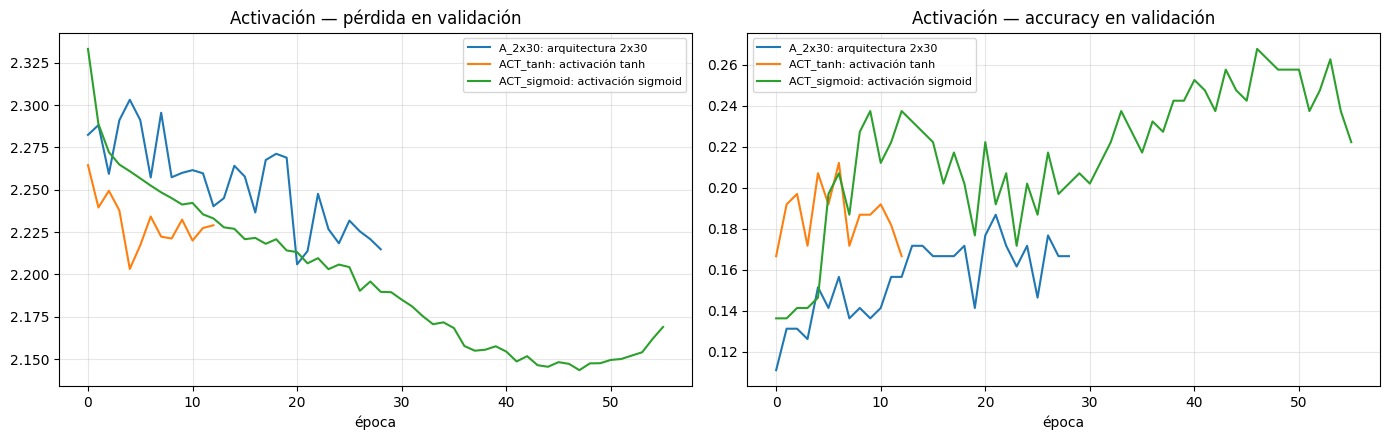

In [24]:
for i, act in zip(["ACT_tanh", "ACT_sigmoid"], ["tanh", "sigmoid"]):
    ejecutar_experimento(i, "activacion", f"activación {act}", activacion=act)
display(tabla([REF, "ACT_tanh", "ACT_sigmoid"]))
graficar([REF, "ACT_tanh", "ACT_sigmoid"], "Activación", "exp_activacion")

> **Interpretación (completar después de ejecutar)**

### 5.7.1 Inicialización de pesos: Glorot vs He

Antes de entrenar, los pesos se inicializan con números al azar centrados en cero. Su tamaño importa: si son muy grandes, la señal crece capa tras capa y el gradiente explota; si son muy pequeños, la señal se achica y el gradiente se desvanece. Las inicializaciones Glorot y He escalan los pesos según la cantidad de neuronas de la capa anterior (k), para que la señal mantenga una intensidad similar al pasar por cada capa:

- **Glorot (Xavier):** pesos al azar multiplicados por √(1/k). Es la que Keras usa por defecto, por lo que es la que se ha usado hasta ahora (referencia).
- **He:** pesos al azar multiplicados por √(2/k). Como ReLU convierte en cero los valores negativos, en promedio anula la mitad de la señal, y el factor 2 lo compensa.

Se compara la referencia (2x30) con Glorot, el valor por defecto de Keras, y con He, cambiando solo la inicialización.

**Hipótesis:** como la red usa ReLU, He debería igualar o mejorar a Glorot. Con solo 2 capas ocultas el efecto podría ser pequeño, porque el desvanecimiento del gradiente se acumula principalmente en redes profundas.

INIT_he   inicialización He              F1 val=0.1111  acc val=0.1919  gap=+0.0454  épocas=14 (10s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,INIT_he,inicialización He,14,6,2.2541,0.1919,0.1048,0.1535,0.1111,0.0454,124150


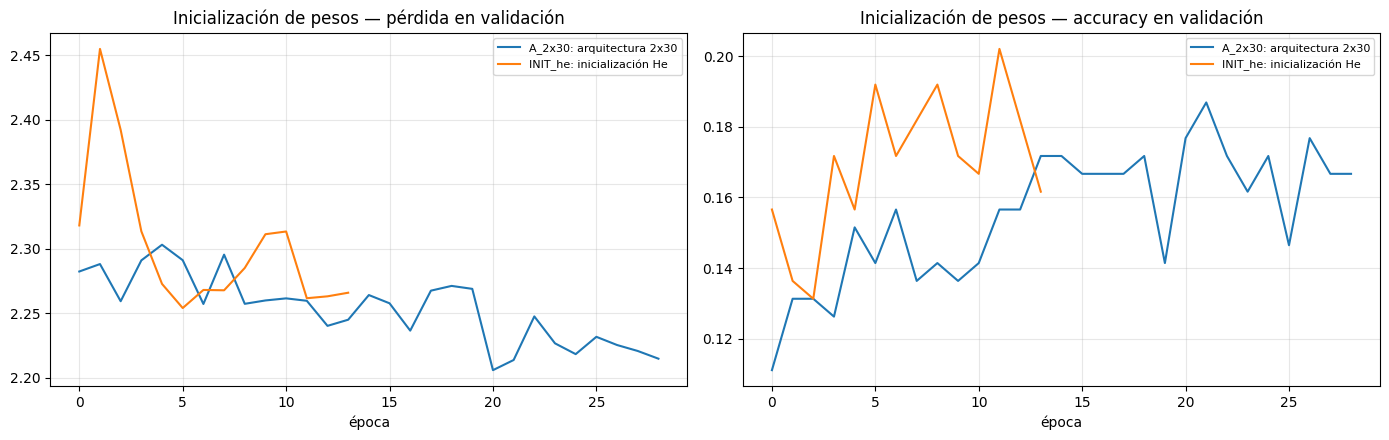

In [26]:
ejecutar_experimento("INIT_he", "inicializacion", "inicialización He", inicializador="he_normal")
display(tabla([REF, "INIT_he"]))
graficar([REF, "INIT_he"], "Inicialización de pesos", "exp_inicializacion")

> **Interpretación (completar después de ejecutar)**

### 5.8 Comparación de funciones de pérdida (con salida softmax)

Como las 10 clases son excluyentes (una radiografía corresponde a un solo tipo de fractura), la función de salida adecuada es softmax, que entrega 10 probabilidades que suman 1. Se comparan tres funciones de pérdida. En los ejemplos, p es la probabilidad que el modelo le asignó a la clase correcta de la imagen:

- **Entropía cruzada categórica** (referencia): pérdida = −Σ yᵢ · log(ŷᵢ). Como la etiqueta está en formato one-hot, se reduce a −log(p). Si p = 0,9, la pérdida es 0,11; si p = 0,1 (como adivinar al azar entre 10 clases), es 2,30; si p = 0,01, es 4,61. Penaliza con fuerza las predicciones seguras y equivocadas.
- **Error cuadrático medio (MSE):** pérdida = promedio de (yᵢ − ŷᵢ)² sobre las 10 clases. Mide la distancia entre el vector one-hot y las probabilidades predichas. Su castigo tiene un techo bajo: considerando solo la clase correcta, si p = 0,9 la pérdida es aproximadamente 0,001; si p = 0,1, 0,081; y si p = 0,01, 0,098. Es decir, un error grave pesa casi lo mismo que uno moderado, lo que entrega una señal débil para corregir los pesos. Se incluye para comprobar por qué la entropía cruzada es preferible en clasificación.
- **Focal loss (γ = 2):** pérdida = −(1 − p)² · log(p). Es la entropía cruzada multiplicada por un factor que reduce casi a cero la pérdida de las imágenes fáciles (con p = 0,9 el factor es 0,01) y mantiene la de las difíciles (con p = 0,1 el factor es 0,81). Así, el entrenamiento se concentra en las imágenes que el modelo aún clasifica mal. Es pertinente por el desbalance entre clases (sección 2.1) y porque varios tipos de fractura son difíciles de distinguir.

Como cada función mide el error en una escala distinta, la val_loss de Keras no sirve para compararlas entre sí. Por eso se comparan con el F1 macro y con la entropía cruzada de validación, calculada igual para los tres modelos.

**Hipótesis:** la entropía cruzada y focal loss superarán a MSE; focal loss podría mejorar las clases menos numerosas.

LOSS_mse  pérdida mse                    F1 val=0.1132  acc val=0.1970  gap=+0.0315  épocas=24 (6s)
LOSS_focal pérdida focal                  F1 val=0.1628  acc val=0.2020  gap=+0.0911  épocas=29 (8s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,LOSS_mse,pérdida mse,24,16,2.2258,0.1970,0.1149,0.1576,0.1132,0.0315,124150
2,LOSS_focal,pérdida focal,29,21,2.1843,0.2020,0.1688,0.1800,0.1628,0.0911,124150


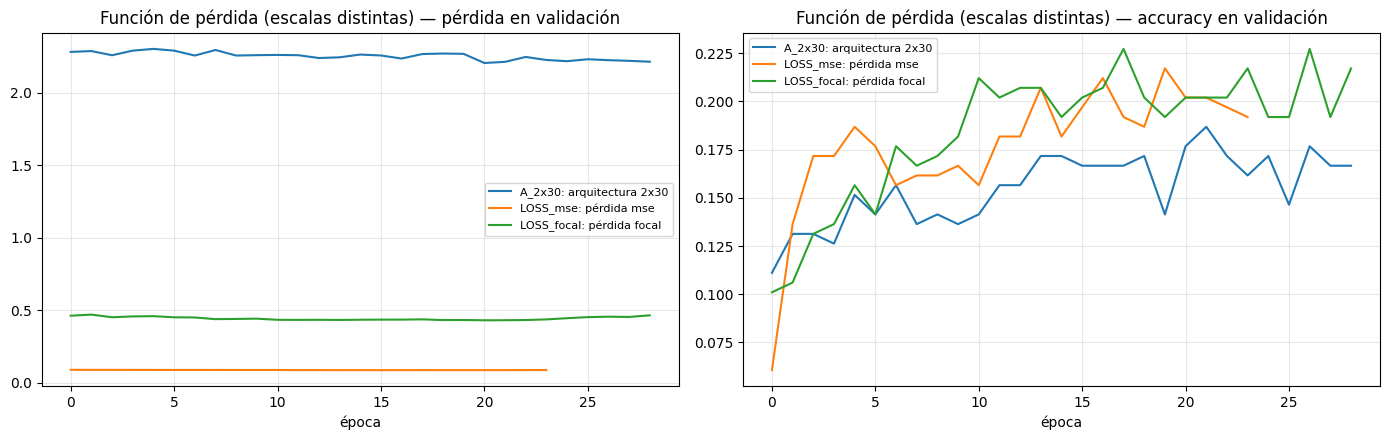

In [27]:
for i, p in zip(["LOSS_mse", "LOSS_focal"], ["mse", "focal"]):
    ejecutar_experimento(i, "perdida", f"pérdida {p}", perdida=p)
display(tabla([REF, "LOSS_mse", "LOSS_focal"]))
graficar([REF, "LOSS_mse", "LOSS_focal"], "Función de pérdida (escalas distintas)", "exp_perdida")

> **Interpretación (completar después de ejecutar)**

### 5.9 Regularización y normalización: con y sin

Se compara la referencia sin regularización con el mismo modelo agregando, de a una técnica por vez:
- **Dropout 0,3:** en cada paso de entrenamiento apaga al azar el 30% de las neuronas; obliga a la red a no depender de neuronas específicas.
- **Regularización L2 (1e-4):** agrega a la pérdida una penalización proporcional al tamaño de los pesos, favoreciendo pesos pequeños.
- **Batch normalization:** normaliza la salida de cada capa en cada lote; suele estabilizar y acelerar el entrenamiento.

**Hipótesis:** si la referencia muestra sobreajuste, dropout y L2 reducirán el gap entre train y validación, aunque quizá converjan más lento.

REG_dropout dropout 0.3                    F1 val=0.0539  acc val=0.1667  gap=-0.0169  épocas=24 (14s)
REG_L2    L2 1e-4                        F1 val=0.1502  acc val=0.1970  gap=+0.0454  épocas=24 (8s)
REG_BN    batch normalization            F1 val=0.1090  acc val=0.1717  gap=+0.1481  épocas=13 (7s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,REG_dropout,dropout 0.3,24,16,2.2644,0.1667,0.0431,0.1261,0.0539,-0.0169,124150
2,REG_L2,L2 1e-4,24,16,2.2310,0.1970,0.2446,0.1685,0.1502,0.0454,124150
3,REG_BN,batch normalization,13,5,2.2555,0.1717,0.1313,0.1396,0.1090,0.1481,124390


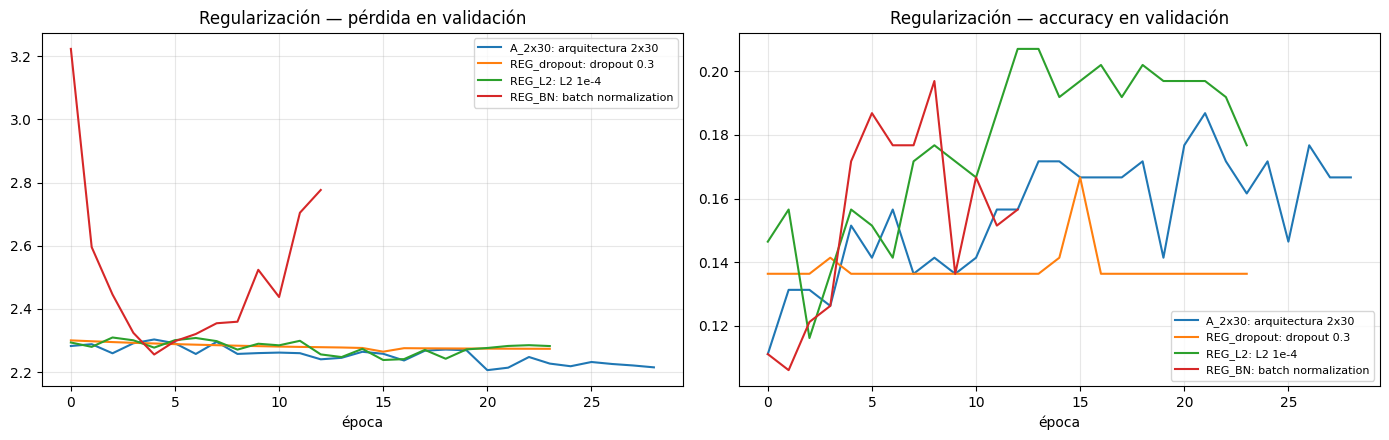

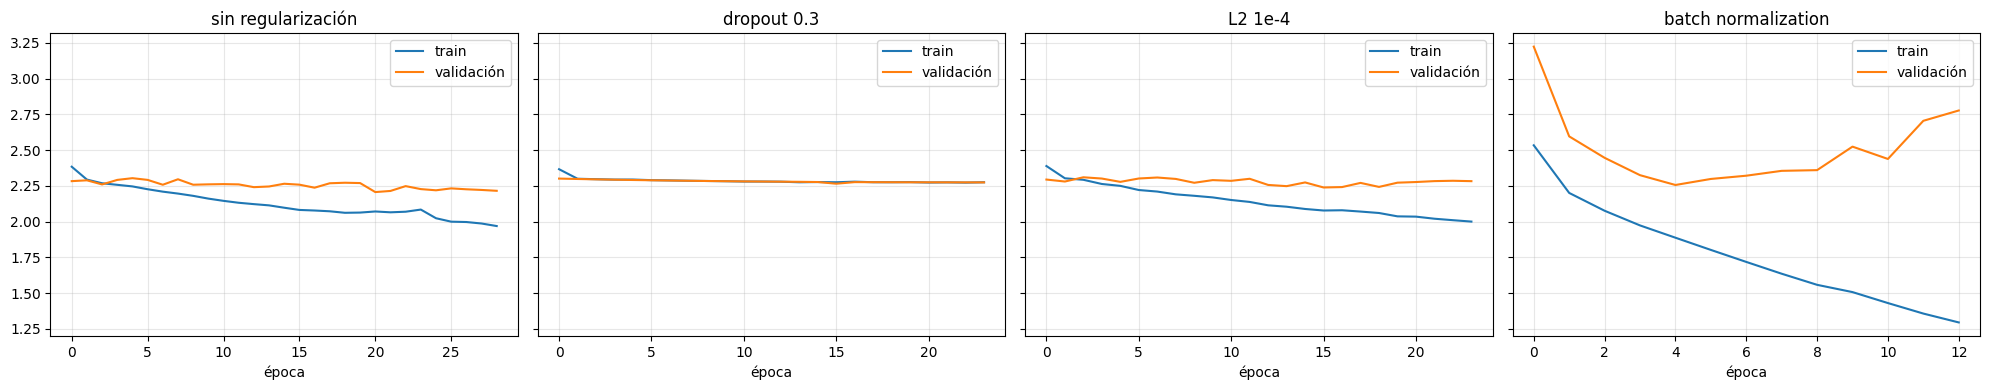

A_2x30: acc train=0.2525 | acc val=0.1768 | gap=+0.0758 | mejor época 21 de 29 → sobreajuste: el modelo rinde claramente mejor en train que en validación
REG_dropout: acc train=0.1497 | acc val=0.1667 | gap=-0.0169 | mejor época 16 de 24 → subajuste: el modelo no logra aprender ni siquiera los datos de entrenamiento
REG_L2: acc train=0.2424 | acc val=0.1970 | gap=+0.0454 | mejor época 16 de 24 → subajuste: el modelo no logra aprender ni siquiera los datos de entrenamiento
REG_BN: acc train=0.3198 | acc val=0.1717 | gap=+0.1481 | mejor época 5 de 13 → sobreajuste: el modelo rinde claramente mejor en train que en validación


In [28]:
ejecutar_experimento("REG_dropout", "regularizacion", "dropout 0.3", dropout=0.3)
ejecutar_experimento("REG_L2", "regularizacion", "L2 1e-4", l2=1e-4)
ejecutar_experimento("REG_BN", "regularizacion", "batch normalization", batch_norm=True)
IDS_REG = [REF, "REG_dropout", "REG_L2", "REG_BN"]
display(tabla(IDS_REG))
graficar(IDS_REG, "Regularización", "exp_regularizacion")

# Gráfico con vs sin regularización: pérdida de train y validación
fig, ax = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for a, i in zip(ax, IDS_REG):
    h = HISTORIALES[i]
    a.plot(h["loss"], label="train"); a.plot(h["val_loss"], label="validación")
    a.set_title(next(r["cambio"] for r in RESULTADOS if r["id"] == i) if i != REF else "sin regularización")
    a.set_xlabel("época"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig("images/con_vs_sin_regularizacion.png", dpi=150); plt.show()
for i in IDS_REG:
    diagnosticar(i)

> **Interpretación (completar después de ejecutar)**

### 5.10 Comparación de optimizadores

Solo cambia el optimizador, con el mismo learning rate (0,001), la misma arquitectura y los mismos pesos iniciales:
- **SGD:** actualiza los pesos en la dirección del gradiente de cada lote.
- **SGD con momentum 0,9:** acumula la dirección de los pasos anteriores; acelera y amortigua oscilaciones.
- **RMSprop:** adapta el tamaño del paso de cada peso según la magnitud reciente de su gradiente.
- **Adam** (referencia): combina momentum y paso adaptativo.

Nota: el learning rate adecuado depende del optimizador (SGD simple suele necesitar valores mayores). Se mantiene 0,001 para aislar el efecto del optimizador; si SGD simple converge muy lento, se explica por esta razón.

OPT_sgd   optimizador sgd                F1 val=0.0944  acc val=0.1818  gap=+0.0568  épocas=100 (21s)
OPT_momentum optimizador sgd_momentum       F1 val=0.1587  acc val=0.2121  gap=+0.1635  épocas=61 (14s)
OPT_rmsprop optimizador rmsprop            F1 val=0.0643  acc val=0.1414  gap=+0.0515  épocas=15 (4s)


,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
1,OPT_sgd,optimizador sgd,100,100,2.2536,0.1818,0.0827,0.1466,0.0944,0.0568,124150
2,OPT_momentum,optimizador sgd_momentum,61,53,2.1601,0.2121,0.1918,0.1799,0.1587,0.1635,124150
3,OPT_rmsprop,optimizador rmsprop,15,7,2.2871,0.1414,0.0541,0.1155,0.0643,0.0515,124150


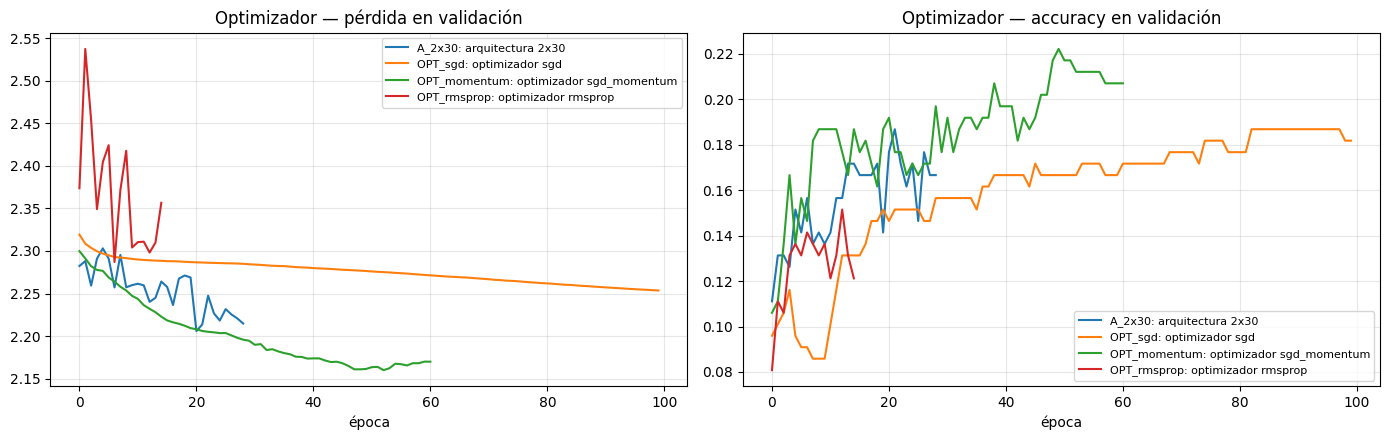

In [29]:
for i, o in zip(["OPT_sgd", "OPT_momentum", "OPT_rmsprop"], ["sgd", "sgd_momentum", "rmsprop"]):
    ejecutar_experimento(i, "optimizador", f"optimizador {o}", optimizador=o)
display(tabla([REF, "OPT_sgd", "OPT_momentum", "OPT_rmsprop"]))
graficar([REF, "OPT_sgd", "OPT_momentum", "OPT_rmsprop"], "Optimizador", "exp_optimizador")

> **Interpretación (completar después de ejecutar)**

### 5.11 Tabla consolidada de experimentos

Una fila por experimento con todas las métricas de validación. La tabla se guarda en results/experimentos.csv.

Los experimentos de resolución (sección 5.2) y de arquitectura (sección 5.3) sirvieron para fijar la configuración de referencia (REF), por lo que se compararon en su propia etapa y en la tabla aparecen como "fase de fijación". Todos los experimentos posteriores (learning rate, batch size, épocas, activación, pérdida, regularización y optimizador) cambian un solo parámetro respecto de REF, y la columna Δ F1 vs REF indica cuánto mejoraron o empeoraron frente a ella.

,id,cambio,img_size,arquitectura,activacion,inicializador,perdida,optimizador,lr,batch,regularizacion,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,Δ F1 vs REF,segundos,conclusión
0,E0,"Baseline (64x64, 4x10)",64,4x10,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,45,37,2.2235,0.1515,0.0464,0.1319,0.0681,0.0185,-0.0613,16.5000,fase de fijación (ver 5.2 / 5.3)
1,RES_32,resolución 32x32,32,4x10,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,34,26,2.2335,0.1465,0.0433,0.1222,0.0638,0.0325,-0.0656,8.7000,fase de fijación (ver 5.2 / 5.3)
2,RES_128,resolución 128x128,128,4x10,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,33,25,2.2488,0.1515,0.0338,0.1200,0.0456,0.0223,-0.0839,12.8000,fase de fijación (ver 5.2 / 5.3)
3,A_4x4,arquitectura 4x4,64,4x4,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,81,73,2.2550,0.1667,0.0609,0.1281,0.0618,0.0072,-0.0676,18.5000,fase de fijación (ver 5.2 / 5.3)
4,A_2x8,arquitectura 2x8,64,2x8,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,68,60,2.2728,0.1364,0.0136,0.1000,0.0240,0.0020,-0.1054,15.0000,fase de fijación (ver 5.2 / 5.3)
5,A_8-4,arquitectura 8-4,64,8-4,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,40,32,2.2674,0.1667,0.0388,0.1222,0.0524,0.0199,-0.0770,10.3000,fase de fijación (ver 5.2 / 5.3)
6,A_16-8,arquitectura 16-8,64,16-8,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,64,56,2.2556,0.1364,0.0252,0.1006,0.0309,0.0299,-0.0985,15.8000,fase de fijación (ver 5.2 / 5.3)
7,A_2x30,arquitectura 2x30,64,2x30,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,0.0000,8.9000,referencia (REF)
8,A_4x30,arquitectura 4x30,64,4x30,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,18,10,2.2053,0.1869,0.0787,0.1434,0.0933,0.0733,-0.0362,5.8000,fase de fijación (ver 5.2 / 5.3)
9,A_2x100,arquitectura 2x100,64,2x100,relu,glorot_uniform,cce,adam,0.0010,32,ninguna,17,9,2.2180,0.1818,0.0860,0.1460,0.0976,0.1075,-0.0318,7.7000,fase de fijación (ver 5.2 / 5.3)


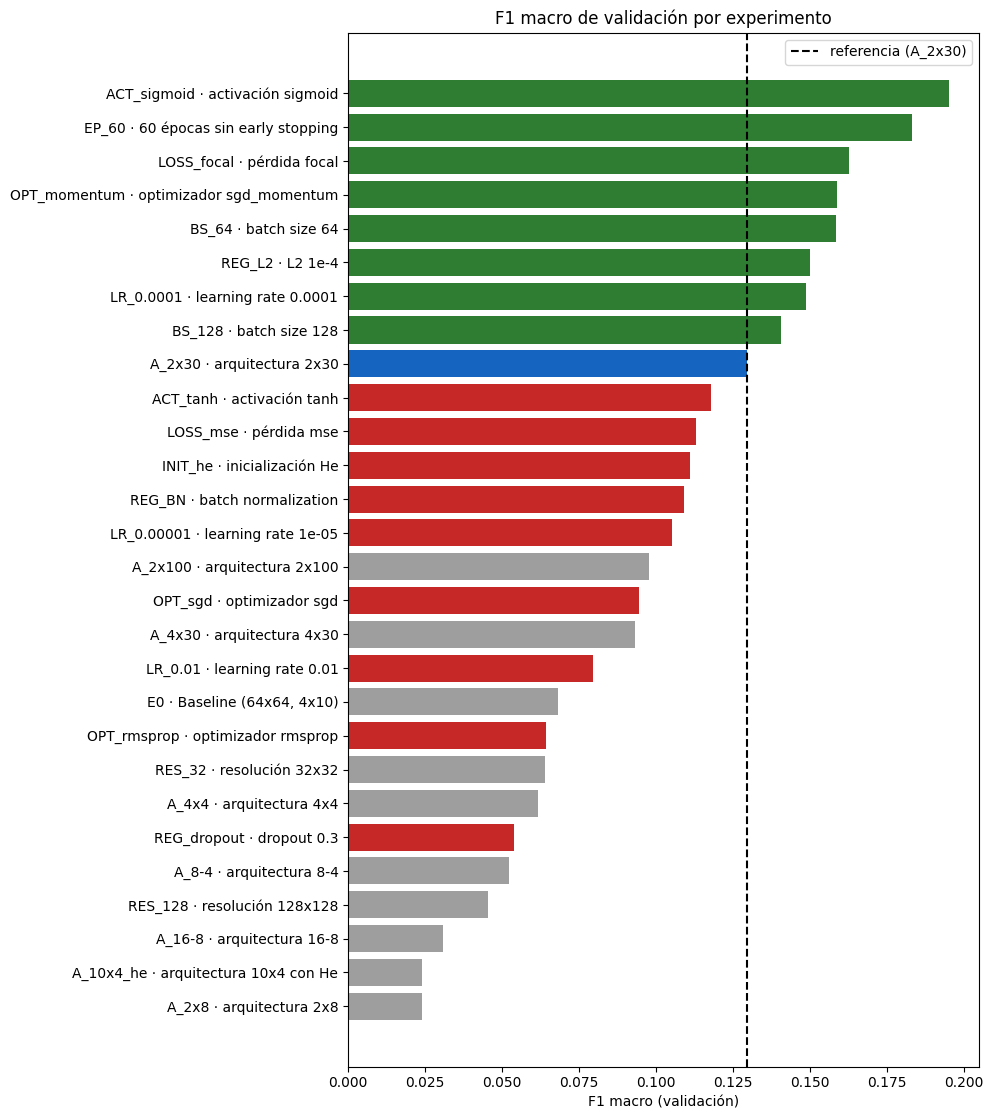

In [31]:
consolidada = pd.DataFrame(RESULTADOS)
consolidada["Δ F1 vs REF"] = consolidada["val_f1"] - f1_ref
fase_fijacion = consolidada["grupo"].isin(["baseline", "resolucion", "arquitectura"])
consolidada["conclusión"] = np.select(
    [consolidada["id"] == REF, fase_fijacion,
     consolidada["Δ F1 vs REF"] >= MIN_MEJORA, consolidada["Δ F1 vs REF"] <= -MIN_MEJORA],
    ["referencia (REF)", "fase de fijación (ver 5.2 / 5.3)", "mejora → candidato", "empeora"],
    default="sin diferencia relevante")
consolidada.to_csv("results/experimentos.csv", index=False)

cols = ["id", "cambio", "img_size", "arquitectura", "activacion", "inicializador", "perdida", "optimizador", "lr", "batch",
        "regularizacion", "epocas_ejecutadas", "mejor_epoca", "val_logloss", "val_accuracy", "val_precision",
        "val_recall", "val_f1", "gap_train_val", "Δ F1 vs REF", "segundos", "conclusión"]
display(consolidada[cols].style.format(precision=4)
        .background_gradient(subset=["val_f1"], cmap="Greens")
        .background_gradient(subset=["gap_train_val"], cmap="Reds"))

orden = consolidada.sort_values("val_f1")
colores = ["#2e7d32" if c.startswith("mejora") else "#c62828" if c == "empeora"
           else "#1565c0" if c.startswith("referencia") else "#9e9e9e" for c in orden["conclusión"]]
plt.figure(figsize=(10, 0.35 * len(orden) + 1.5))
plt.barh(orden["id"] + " · " + orden["cambio"], orden["val_f1"], color=colores)
plt.axvline(f1_ref, ls="--", c="k", label=f"referencia ({REF})")
plt.xlabel("F1 macro (validación)"); plt.legend(); plt.title("F1 macro de validación por experimento")
plt.tight_layout(); plt.savefig("images/resumen_experimentos_f1.png", dpi=150, bbox_inches="tight"); plt.show()

> **Interpretación (completar después de ejecutar)**

### 5.12 Selección del modelo final (solo con validación)

El modelo final es el que se evaluará una sola vez en test (sección 6). Se elige con esta regla, definida antes de ver los resultados:

1. Para cada grupo de experimentos (learning rate, batch size, activación, pérdida, regularización y optimizador) se adopta la mejor alternativa solo si supera a la referencia (REF) en al menos 0,005 de F1 macro; si no, se mantiene el valor de REF.
2. Se entrena un experimento llamado COMBINADO, que aplica a la vez todos los cambios adoptados. Por ejemplo, si focal loss y batch size 64 mejoraron por separado, COMBINADO usa ambos.
3. Se compara COMBINADO con el mejor experimento individual, porque las mejoras no siempre se suman al combinarlas: a veces dos cambios que ayudan por separado se estorban juntos.
4. El modelo final es el que tenga mayor F1 macro en validación, sea COMBINADO o el mejor experimento individual.

In [32]:
# Parámetro que modifica cada experimento respecto de la referencia (REF)
CAMBIOS_EXP = {
    "LR_0.01": {"learning_rate": 1e-2}, "LR_0.0001": {"learning_rate": 1e-4},
    "LR_0.00001": {"learning_rate": 1e-5},
    "BS_64": {"batch_size": 64}, "BS_128": {"batch_size": 128},
    "ACT_tanh": {"activacion": "tanh"}, "ACT_sigmoid": {"activacion": "sigmoid"},
    "INIT_he": {"inicializador": "he_normal"},
    "LOSS_mse": {"perdida": "mse"}, "LOSS_focal": {"perdida": "focal"},
    "REG_dropout": {"dropout": 0.3}, "REG_L2": {"l2": 1e-4}, "REG_BN": {"batch_norm": True},
    "OPT_sgd": {"optimizador": "sgd"}, "OPT_momentum": {"optimizador": "sgd_momentum"},
    "OPT_rmsprop": {"optimizador": "rmsprop"},
}

# Cambios adoptados: el mejor de cada grupo, si supera a REF en al menos MIN_MEJORA de F1
cambios_adoptados = {}
decisiones = [("resolución", f"fijada en la sección 5.2.1: {BASELINE['img_size']}x{BASELINE['img_size']}", None),
              ("arquitectura", f"fijada en la sección 5.3.1: {mejor_arq['arquitectura']}", None)]
for grupo in ["learning_rate", "batch_size", "activacion", "inicializacion", "perdida", "regularizacion", "optimizador"]:
    g = consolidada[consolidada["grupo"] == grupo].sort_values(["val_f1", "val_logloss"], ascending=[False, True])
    mejor = g.iloc[0]
    if mejor["val_f1"] - f1_ref >= MIN_MEJORA:
        cambios_adoptados.update(CAMBIOS_EXP[mejor["id"]])
        decisiones.append((grupo, f"se adopta {mejor['id']} ({mejor['cambio']})", mejor["val_f1"] - f1_ref))
    else:
        decisiones.append((grupo, "se mantiene la referencia", mejor["val_f1"] - f1_ref))

display(pd.DataFrame(decisiones, columns=["grupo", "decisión", "Δ F1 vs REF"])
        .style.format({"Δ F1 vs REF": lambda v: "—" if pd.isna(v) else f"{v:+.4f}"}))

,grupo,decisión,Δ F1 vs REF
0,resolución,fijada en la sección 5.2.1: 64x64,—
1,arquitectura,fijada en la sección 5.3.1: 2x30,—
2,learning_rate,se adopta LR_0.0001 (learning rate 0.0001),+0.0194
3,batch_size,se adopta BS_64 (batch size 64),+0.0290
4,activacion,se adopta ACT_sigmoid (activación sigmoid),+0.0657
5,inicializacion,se mantiene la referencia,-0.0183
6,perdida,se adopta LOSS_focal (pérdida focal),+0.0334
7,regularizacion,se adopta REG_L2 (L2 1e-4),+0.0208
8,optimizador,se adopta OPT_momentum (optimizador sgd_momentum),+0.0293


#### 5.12.1 Experimento COMBINADO

Se entrena la configuración de referencia aplicando a la vez todos los cambios adoptados en la tabla anterior.

In [33]:
modelo_comb, fila_comb = ejecutar_experimento("COMBINADO", "combinado", "combinación de los cambios adoptados",
                                              **cambios_adoptados)
display(pd.Series({**BASELINE, **cambios_adoptados}, name="valor").to_frame().rename_axis("parámetro"))

COMBINADO combinación de los cambios adoptados F1 val=0.0240  acc val=0.1364  gap=-0.0006  épocas=100 (26s)


,valor
parámetro,
img_size,64
capas,"(30, 30)"
activacion,sigmoid
inicializador,glorot_uniform
dropout,0.0
l2,0.0001
batch_norm,False
optimizador,sgd_momentum
learning_rate,0.0001


#### 5.12.2 Elección del modelo final

Se compara el experimento COMBINADO con el mejor experimento individual. El modelo final es el de mayor F1 macro en validación.

In [34]:
# Mejor experimento individual
candidatos = consolidada[~consolidada["grupo"].isin(["epocas", "resolucion", "arquitectura", "baseline"])
                         | (consolidada["id"] == REF)]
mejor_ind = candidatos.sort_values(["val_f1", "val_logloss"], ascending=[False, True]).iloc[0]

# Modelo final: el de mayor F1 en validación entre COMBINADO y el mejor individual
if fila_comb["val_f1"] >= mejor_ind["val_f1"]:
    modelo_final, fila_final, CONFIG_FINAL = modelo_comb, fila_comb, {**BASELINE, **cambios_adoptados}
else:
    cambios = CAMBIOS_EXP.get(mejor_ind["id"], {})
    modelo_final, fila_final = ejecutar_experimento(mejor_ind["id"], mejor_ind["grupo"], mejor_ind["cambio"], **cambios)
    CONFIG_FINAL = {**BASELINE, **cambios}
ID_FINAL = fila_final["id"]

print(f"Modelo final: {ID_FINAL} (F1 macro en validación: {fila_final['val_f1']:.4f})\n")
display(tabla(list(dict.fromkeys(["E0", REF, mejor_ind["id"], "COMBINADO", ID_FINAL]))))
display(pd.Series(CONFIG_FINAL, name="valor").to_frame().rename_axis("parámetro"))

ACT_sigmoid activación sigmoid             F1 val=0.1951  acc val=0.2626  gap=+0.1409  épocas=56 (14s)
Modelo final: ACT_sigmoid (F1 macro en validación: 0.1951)



,id,cambio,epocas_ejecutadas,mejor_epoca,val_logloss,val_accuracy,val_precision,val_recall,val_f1,gap_train_val,parametros
0,E0,"Baseline (64x64, 4x10)",45,37,2.2235,0.1515,0.0464,0.1319,0.0681,0.0185,41410
1,A_2x30,arquitectura 2x30,29,21,2.2059,0.1768,0.1325,0.1537,0.1294,0.0758,124150
2,ACT_sigmoid,activación sigmoid,56,48,2.1434,0.2626,0.2200,0.2233,0.1951,0.1409,124150
3,COMBINADO,combinación de los cambios adoptados,100,100,2.4231,0.1364,0.0136,0.1000,0.0240,-0.0006,124150


,valor
parámetro,
img_size,64
capas,"(30, 30)"
activacion,sigmoid
inicializador,glorot_uniform
dropout,0.0
l2,0.0
batch_norm,False
optimizador,adam
learning_rate,0.001


#### 5.12.3 Curvas de entrenamiento del modelo final

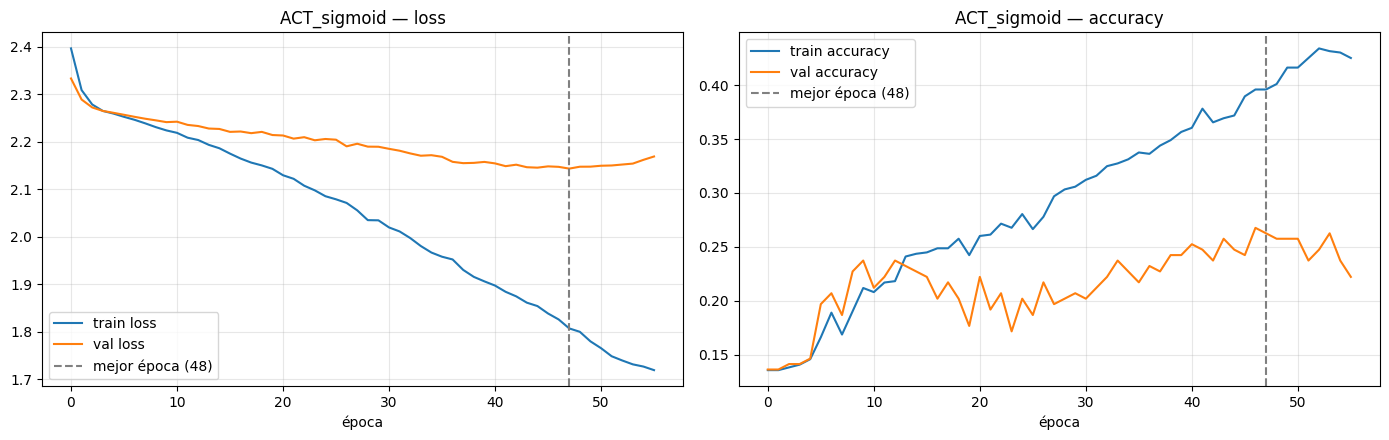

ACT_sigmoid: acc train=0.4036 | acc val=0.2626 | gap=+0.1409 | mejor época 48 de 56 → sobreajuste: el modelo rinde claramente mejor en train que en validación


In [35]:
curvas_train_val(ID_FINAL, "curvas_modelo_final")
diagnosticar(ID_FINAL)

> **Interpretación (completar después de ejecutar)**

### 5.13 Variabilidad por semilla

Para saber si las diferencias entre experimentos son mayores que el efecto del azar, la configuración final se entrena con tres semillas y se reporta promedio y desviación estándar en validación. No se elige la mejor semilla: el modelo final sigue siendo el entrenado con SEED = 42.

In [36]:
f1s = []
for s in [1, 42, 80]:
    _, fila = ejecutar_experimento(f"SEED_{s}", "semilla", f"semilla {s}", guardar=False, seed=s, **CONFIG_FINAL)
    f1s.append(fila["val_f1"])
reiniciar_semillas()
print(f"\nF1 macro de validación: {np.mean(f1s):.4f} ± {np.std(f1s, ddof=1):.4f} (3 semillas)")
print("Las diferencias entre experimentos menores que esta desviación deben interpretarse con cautela.")

SEED_1    semilla 1                      F1 val=0.1417  acc val=0.1970  gap=+0.1990  épocas=36 (10s)
SEED_42   semilla 42                     F1 val=0.1951  acc val=0.2626  gap=+0.1409  épocas=56 (15s)
SEED_80   semilla 80                     F1 val=0.1526  acc val=0.1919  gap=+0.1596  épocas=40 (11s)

F1 macro de validación: 0.1631 ± 0.0282 (3 semillas)
Las diferencias entre experimentos menores que esta desviación deben interpretarse con cautela.


> **Interpretación (completar después de ejecutar)**

### 5.14 Guardado del modelo y de la configuración final

In [37]:
modelo_final.save("models/modelo_mlp_final.keras")
with open("results/configuracion_final.json", "w") as f:
    json.dump({"id": ID_FINAL, "seed": SEED, "clases": CLASES,
               **{k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG_FINAL.items()}}, f, indent=2)
print("Guardado: models/modelo_mlp_final.keras y results/configuracion_final.json")

Guardado: models/modelo_mlp_final.keras y results/configuracion_final.json


## 6. Evaluación final en test

La configuración quedó cerrada en la sección 5.12 usando solo validación. Ahora el modelo final se evalúa una sola vez sobre las imágenes de las carpetas Test. Estos resultados no se usan para volver a modificar el modelo.

In [ ]:
X_test_final = DATOS[CONFIG_FINAL["img_size"]]["X"][2]
p_test = modelo_final.predict(X_test_final, batch_size=1024, verbose=0)
y_pred = p_test.argmax(1)            # clase con mayor probabilidad
confianza = p_test.max(1)            # probabilidad asignada a esa clase

resumen_test = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision (macro)": [precision_score(y_test, y_pred, average="macro", zero_division=0)],
    "Recall (macro)": [recall_score(y_test, y_pred, average="macro", zero_division=0)],
    "F1 (macro)": [f1_score(y_test, y_pred, average="macro")],
}, index=[f"Test — {ID_FINAL}"])
display(resumen_test.style.format("{:.4f}"))
print(classification_report(y_test, y_pred, target_names=CLASES, digits=3, zero_division=0))

# **HASTA AQUÍ HA SIDO MODIFICADO**

> El modelo SGD final obtiene 78,5% de accuracy en test (F1 macro: 0,782). Por clase, forest y glacier tienen el mejor desempeño (F1 0,85 y 0,82 respectivamente), mientras que buildings sigue siendo la más débil (F1 0,68, recall 0,70) — aunque mejoró bastante respecto a la corrida con batch=64 (recall 0,64). La matriz de confusión muestra que buena parte de sus errores se siguen confundiendo con las otras dos clases, probablemente porque comparte fondo de cielo y a veces vegetación urbana con forest y glacier.

In [ ]:
# Matriz confusión Adam

y_pred_adam_probs = modelo_adam.predict(test_gen)
y_pred_adam = np.argmax(y_pred_adam_probs, axis=1)

print("Accuracy :", accuracy_score(y_true, y_pred_adam))
print("Precision:", precision_score(y_true, y_pred_adam, average="macro"))
print("Recall   :", recall_score(y_true, y_pred_adam, average="macro"))
print("F1       :", f1_score(y_true, y_pred_adam, average="macro"))

cm_adam = confusion_matrix(y_true, y_pred_adam)
plt.figure(figsize=(6,5))
sns.heatmap(cm_adam, annot=True, fmt="d", xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión — Adam")
plt.savefig(f"{base}/images/matriz_confusion_adam.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred_adam, target_names=clases))

> Como referencia, el modelo Adam (no elegido como final) obtiene 76,9% de accuracy y F1 macro 0,762, esta vez por debajo de SGD en las tres métricas. Su mayor debilidad está en buildings, donde solo alcanza recall 0,62 (contra 0,70 de SGD), lo que explica buena parte de la diferencia total a favor de SGD en esta configuración final.

### Gap train-test — SGD

Compara el accuracy en entrenamiento vs en test para cuantificar el sobreajuste de forma numérica, en vez de solo inferirlo mirando las curvas de loss.

In [ ]:
train_loss, train_acc = modelo.evaluate(train_gen, verbose=0)
test_loss, test_acc = modelo.evaluate(test_gen, verbose=0)
gap = train_acc - test_acc

print(f"Accuracy train: {train_acc:.4f}")
print(f"Accuracy test : {test_acc:.4f}")
print(f"Gap (train - test): {gap:.4f}")

> El accuracy en entrenamiento (86,5%) supera al de test (78,5%) por 8,0 puntos porcentuales, un gap algo mayor que con batch=64 (6,6 puntos), pero coherente: con batch=32 el modelo también aprendió más en general (mayor accuracy tanto en train como en test), así que no es necesariamente peor sobreajuste relativo, sino un modelo que extrajo más patrones de los datos de entrenamiento en total.

## 7. Análisis de resultados y errores

Se examinan ejemplos correctos e incorrectos de clasificación para identificar qué clases se confunden más y por qué, discutiendo las limitaciones del MLP para este problema.

In [ ]:
# El modelo final elegido es SGD, por lo tanto el análisis de errores se basa en sus predicciones
y_pred = y_pred_sgd

In [ ]:
errores_idx = np.where(y_pred != y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), errores_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/errores_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

> La salida del código anterior muestra 9 ejemplos de imágenes mal clasificadas, filtrando únicamente los casos donde la predicción no coincide con la clase real. No representa el total de errores del modelo.

In [ ]:
total_test = len(y_true)
total_errores = np.sum(y_pred != y_true)
total_aciertos = total_test - total_errores

print(f"Total de imágenes en test : {total_test}")
print(f"Clasificadas correctamente: {total_aciertos} ({total_aciertos/total_test:.1%})")
print(f"Clasificadas incorrectamente: {total_errores} ({total_errores/total_test:.1%})")

> Del total de 1.464 imágenes de test, el modelo clasifica correctamente el 78,5% (1.149 imágenes) y falla en el 21,5% restante (315 imágenes), coincidiendo con el accuracy reportado en la sección de evaluación.

In [ ]:
print("\nErrores por clase real:")
for i, clase in enumerate(clases):
    idx_clase = (y_true == i)
    errores_clase = np.sum(y_pred[idx_clase] != y_true[idx_clase])
    total_clase = np.sum(idx_clase)
    print(f"  {clase}: {errores_clase}/{total_clase} ({errores_clase/total_clase:.1%})")

> El desglose por clase muestra que buildings sigue concentrando la mayor proporción de errores (30,4%), seguida de glacier (18,4%), mientras que forest es la clase con menos errores (16,9%). El orden entre clases se mantiene igual que en corridas anteriores, aunque los tres porcentajes de error bajaron con esta configuración final. Es consistente con la matriz de confusión: buildings comparte fondo de cielo y a veces vegetación con las otras dos clases, lo que dificulta distinguirla.

In [ ]:
correctos_idx = np.where(y_pred == y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), correctos_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/aciertos_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

> La salida de código anterior muestra 9 ejemplos clasificados correctamente. Como `correctos_idx` toma los primeros índices en el orden del generador de test (agrupado alfabéticamente por carpeta), las 9 imágenes corresponden todas a la clase "buildings".

### Entorno de ejecución

Registra las versiones de las librerías principales usadas, para dejar
trazabilidad de en qué entorno se obtuvieron los resultados reportados.

In [ ]:
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

> Se registran las versiones de TensorFlow (2.20.0) y NumPy (2.1.3) usadas en esta corrida, como parte de la trazabilidad exigida por la pauta (permite reproducir el entorno exacto si el notebook se ejecuta en otra máquina).

Los resultados anteriores evidencian una limitación estructural del MLP para este tipo de problema, más allá de cualquier ajuste de hiperparámetros. Al aplicar Flatten sobre las imágenes (64×64×3 → 12.288 valores), el modelo trata cada píxel como una variable independiente y descarta por completo la información espacial: no existe ningún mecanismo que le indique al modelo qué píxeles están cerca de cuáles. Esto ayuda a explicar por qué buildings es la clase más difícil de las tres: comparte con forest y glacier colores y texturas globales (cielo, tonos grises/verdes), pero el modelo no puede aprovechar bordes, formas o patrones locales, como líneas rectas de edificios, para diferenciarla, porque esa información 2D se pierde en el aplanado. Es una limitación de diseño, no de entrenamiento: aumentar la resolución, agregar neuronas o entrenar más épocas no ataca el problema de fondo, solo incrementa el costo computacional. Una arquitectura convolucional (CNN), que preserva la estructura espacial mediante filtros locales, es el paso natural para superar esta limitación.



---


## Anexo: Conclusiones y justificaciones adicionales

### Qué comprobamos realmente

Nuestro resultado principal no es solo el 78,5% de accuracy en test. Es haber mostrado el efecto de decisiones concretas sobre el desempeño del modelo:

- **Reducir la resolución** (de 150×150 original a 64×64) controló el crecimiento del número de parámetros del MLP, que con Flatten escala directamente con el tamaño de la imagen.
- **Una arquitectura de 4 capas × 10 neuronas** (123.253 parámetros) equilibró capacidad y costo computacional frente a alternativas descartadas: una red más chica (4×4) rindió peor, y una más grande (256→128 con Dropout) no se justificaba para el tamaño del subconjunto de datos usado.
- **Batch size 32** dio mejor resultado que 64 y 128 bajo la misma arquitectura, tanto en accuracy final como en velocidad de convergencia de SGD (época 37 vs época 93 con batch=64).
- **EarlyStopping** (monitor val_loss, patience=5) evitó seguir entrenando una vez que el modelo dejó de mejorar en validación, y permitió comparar Adam y SGD de forma justa sin fijar arbitrariamente el número de épocas.
- **SGD**, aunque convergió más lento que Adam (época 37 vs época 12-13), alcanzó finalmente la mejor solución de esta corrida: 78,5% de accuracy y F1 macro 0,782, contra 76,9% y 0,762 de Adam.
- El análisis de la matriz de confusión y el desglose de errores por clase mostraron consistentemente que **buildings es la clase crítica** (F1 0,68, 30,4% de error), mientras que forest (F1 0,85) y glacier (F1 0,82) se clasifican con mayor fiabilidad.

### Limitaciones reconocidas

- La arquitectura MLP pierde información espacial al aplanar la imagen (ver discusión en la sección 7), lo que limita su capacidad para distinguir clases que comparten texturas o colores globales.
- La comparación de configuraciones (arquitectura, batch size, optimizador) se apoyó en el desempeño observado sobre el propio conjunto de test, en lugar de basarse exclusivamente en el conjunto de validación. Esto es una desviación metodológica que debe corregirse en una siguiente iteración: idealmente, todas las decisiones de diseño se toman mirando solo train/validation, y el test se reserva únicamente para una evaluación final, única y aislada, del modelo ya elegido.
- Se probaron tres semillas distintas (SEED=1, SEED=42 y SEED=80) para verificar que el resultado no dependiera de una inicialización particular; SEED=42 fue la que entregó el mejor desempeño y es la que se reporta en este notebook como configuración final. Sin embargo, no se promediaron ni reportaron aquí las métricas de las tres corridas de forma sistemática (solo se usó el resultado de la mejor), por lo que no queda documentada la variabilidad real entre semillas ni cuánto del resultado final se explica por la elección de SEED=42 versus una mejora genuina de la configuración.

### Siguiente paso propuesto

Dado lo anterior, el siguiente paso natural sería implementar una **CNN pequeña**, incorporando **data augmentation** (para compensar el tamaño limitado del subconjunto de 3 clases) y **reportando de forma sistemática el resultado de las distintas semillas probadas** (por ejemplo, promedio y desviación estándar sobre SEED=1, 42 y 80), en vez de reportar solo la mejor corrida. Esto permitiría separar el efecto real de las decisiones de diseño de la variabilidad propia de la inicialización aleatoria, y mantener además el conjunto de test completamente aislado de cualquier decisión de ajuste.

### Justificaciones y aclaraciones adicionales

- **Sobre la estructura de carpetas del proyecto:** el proyecto se aloja en un repositorio de GitHub, donde son visibles las carpetas `data/`, `notebooks/`, `models/` e `images/`, además de `.git`, `.gitignore` y `README.md`. Esta estructura se crea automáticamente al inicio del notebook (ver bloque de "Estructura de carpetas del proyecto local"), pero se documenta aquí explícitamente para quien revise el trabajo sin acceso directo al repositorio:
  - `data/`: contiene el dataset descargado desde Kaggle (`intel_images/`).
  - `notebooks/`: contiene este notebook.
  - `models/`: contiene el modelo final entrenado (`modelo_mlp.keras`).
  - `images/`: contiene todos los gráficos generados (distribución de clases, curvas de entrenamiento, matrices de confusión, ejemplos de aciertos/errores).
- **Sobre por qué se descartaron la Arquitectura 1 y la Arquitectura 2:** la Arquitectura 1 (256→128 neuronas con Dropout) resultaba sobredimensionada para un problema de solo 3 clases y ~5.500 imágenes de entrenamiento, aumentando el riesgo de sobreajuste sin necesidad. La Arquitectura 2 (4×4 neuronas) resultó insuficiente en capacidad al compararla directamente contra la de 4×10 bajo las mismas condiciones (batch=64), por lo que se descartó a favor de esta última.